# **🌴Spatial Heterogeneity and Regional Distribution of Forest Ecosystems in Pakistan: A Comparative Assessment**

# **About the Author:**

**Name: Adil Zaman**

**Email ID : zamanandil61@gmail.com**

**Kaggle ID: https://www.kaggle.com/zemnukes98**

**Linkedin ID : https://www.linkedin.com/in/adil-zaman-85b56a398/**

# **🌴A Geospatial and Categorical Inventory of Pakistan’s Forest Cover:**

>**This inventory maps 11,894 units across six administrative regions, categorizing Pakistan’s greenery into nine distinct types from natural Coniferous and Coastal forests to managed Irrigated plantations. The data reveals sharp ecological contrasts, such as Punjab’s dominance in miscellaneous land and Balochistan’s unique concentration of Linear and Mazri vegetation. By documenting regional absences and concentrations, the dataset provides a vital baseline for comparative analysis and strategic land management across the country’s diverse environmental niches.**

# **🌴Strategic Assessment of Regional Forest Distribution and Ecological Composition in Pakistan:**

>**The primary objective of this dataset is to provide a comprehensive statistical framework for evaluating the distribution and density of diverse forest types across Pakistan's administrative regions. It aims to facilitate a comparative analysis between natural ecosystems and managed plantations, enabling stakeholders to identify regional resource disparities and prioritize specific conservation needs. By aggregating area-specific data, the dataset serves as a foundational tool for monitoring national land-use patterns and developing evidence-based strategies for sustainable forestry management.**

# **🌲 Pakistan Forest Dataset — Complete ML/DL/NLP Analysis**

**Objectives:** **Statistical profiling · 20+ ML models (regressors & classifiers) · PyTorch DL · NLP · PCA · Clustering · 5–10 year forecasting · Evidence-based conservation decisions**


## **1. Imports & Global Setup**

This code initializes a robust data science environment by importing essential libraries for data manipulation (Pandas, NumPy), advanced visualization (Matplotlib, Seaborn), and comprehensive machine learning workflows using Scikit-Learn. It sets up an extensive toolkit for regression, classification, clustering, and deep learning via PyTorch, alongside specialized gradient boosting frameworks like XGBoost and LightGBM. Additionally, it configures Natural Language Processing (NLP) resources and applies a custom "Forest" themed aesthetic to plots, ensuring the environment is optimized for both rigorous statistical modeling and high-quality visual storytelling.

In [1]:
import warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap

# Sklearn preprocessing & metrics
from sklearn.preprocessing import (LabelEncoder, StandardScaler,
                                   MinMaxScaler, PolynomialFeatures)
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, KFold)
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, classification_report,
                              confusion_matrix, accuracy_score,
                              f1_score, silhouette_score)
from sklearn.pipeline import Pipeline

# Sklearn regressors
from sklearn.linear_model import (LinearRegression, Ridge, Lasso,
                                  ElasticNet, BayesianRidge, HuberRegressor)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               AdaBoostRegressor, ExtraTreesRegressor,
                               BaggingRegressor, VotingRegressor)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

# Sklearn classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, ExtraTreesClassifier,
                               BaggingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

# Sklearn unsupervised
from sklearn.decomposition import PCA
from sklearn.cluster import (KMeans, AgglomerativeClustering, DBSCAN,
                              SpectralClustering)
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage

# XGBoost & LightGBM
import xgboost as xgb
import lightgbm as lgb

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# NLP
import nltk, re
from collections import Counter
from nltk.tokenize import word_tokenize
try:
    nltk.download('punkt_tab', quiet=True)
except: pass
from nltk.corpus import stopwords

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
try:
    nltk.download('punkt_tab', quiet=True)
except: pass

# Colour palette
FOREST_COLORS = ['#2D6A4F','#40916C','#52B788','#74C69D',
                 '#95D5B2','#B7E4C7','#D8F3DC','#1B4332']
REGION_COLORS = ['#E07A5F','#3D405B','#81B29A','#F2CC8F','#A8DADC','#457B9D']

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor' : '#F9FBF9',
    'axes.grid'      : True,
    'grid.alpha'     : 0.3,
    'font.size'      : 11,
})
print("✅ All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")


✅ All libraries imported successfully!
PyTorch version: 2.11.0+cpu
CUDA available : False


## **2. Data Loading, Cleaning & Feature Engineering**

This code performs comprehensive data preprocessing by cleaning the raw dataset, removing aggregate rows, and standardizing regional values into a numeric format for analysis. It engineers advanced features like the Herfindahl-Hirschman Index (HHI) and Gini coefficients to quantify the geographic concentration and diversity of different forest types across Pakistan. Additionally, it categorizes and encodes the forests into ecological groups such as "Natural" or "Plantation" before exporting the refined dataset into a new CSV file ready for machine learning or statistical modeling.

In [3]:
# ── Load raw data ──
raw = pd.read_csv('Forets.csv')
print("Raw shape:", raw.shape)
raw.head(10)

# ── Clean: drop Grand Total row, replace '-' with 0, fix dtypes ──
df = raw[raw['Forest Type'] != 'Grand Total'].copy()
region_cols = ['Punjab','KPK','Sindh','Balochistan','Azad Kashmir',' Gilgit Baltistan']
df[region_cols] = df[region_cols].replace('-', '0').apply(
    lambda c: pd.to_numeric(c.astype(str).str.strip(), errors='coerce').fillna(0))
df['Total'] = df[region_cols].sum(axis=1)
df.rename(columns={' Gilgit Baltistan':'Gilgit_Baltistan',
                    'Azad Kashmir':'Azad_Kashmir',
                    'Forest Type':'Forest_Type'}, inplace=True)
region_cols = ['Punjab','KPK','Sindh','Balochistan','Azad_Kashmir','Gilgit_Baltistan']

# ── Feature Engineering ──
df['Dominant_Region']    = df[region_cols].idxmax(axis=1)
df['Region_Count']       = (df[region_cols] > 0).sum(axis=1)
df['Max_Region_Share']   = df[region_cols].max(axis=1) / df['Total']
df['HHI']                = (df[region_cols].div(df['Total'], axis=0)**2).sum(axis=1)  # concentration
df['Gini_approx']        = df[region_cols].apply(
    lambda r: 1 - sum((r/r.sum())**2) if r.sum()>0 else 0, axis=1)

# Categorical label
df['Type_Category'] = df['Forest_Type'].map({
    'Coniferous Forests':'Natural','Riverain Forests':'Natural',
    'Scrub Forests':'Natural','Coastal Forests':'Natural',
    'Range Land':'Natural','Mazri':'Natural',
    'Irrigated Plantations':'Plantation',
    'Linear Plantations':'Plantation',
    'Miscellaneous':'Mixed'})
df['Type_Category'].fillna('Natural', inplace=True)

le = LabelEncoder()
df['Type_Category_enc'] = le.fit_transform(df['Type_Category'])

print("Cleaned shape:", df.shape)
df.to_csv('forest_clean.csv', index=False)
print(df[['Forest_Type','Total','Region_Count','HHI','Type_Category']].to_string())



Raw shape: (10, 8)
Cleaned shape: (9, 15)
             Forest_Type  Total  Region_Count       HHI Type_Category
0     Coniferous Forests   1712             5  0.288278       Natural
1  Irrigated Plantations    738             4  0.426154    Plantation
2       Riverain Forests    488             3  0.375176       Natural
3          Scrub Forests   1344             4  0.375209       Natural
4        Coastal Forests    519             2  0.554278       Natural
5     Linear Plantations    696             2  0.994269    Plantation
6                  Mazri    371             2  0.878990       Natural
7             Range Land   1795             6  0.247774       Natural
8          Miscellaneous   4231             3  0.539034         Mixed


## **3. Exploratory Data Analysis (EDA)**

This code constructs a multi-panel exploratory dashboard that visualizes the distribution, regional makeup, and geographic concentration of Pakistan’s forest cover. Through a combination of horizontal bar charts, pie charts, and stacked visualizations, it effectively compares total area by forest type while a heatmap highlights regional density hotspots. Furthermore, it utilizes the Herfindahl-Hirschman Index (HHI) to measure habitat concentration, resulting in a comprehensive statistical and spatial summary rendered as a high-resolution thematic image.


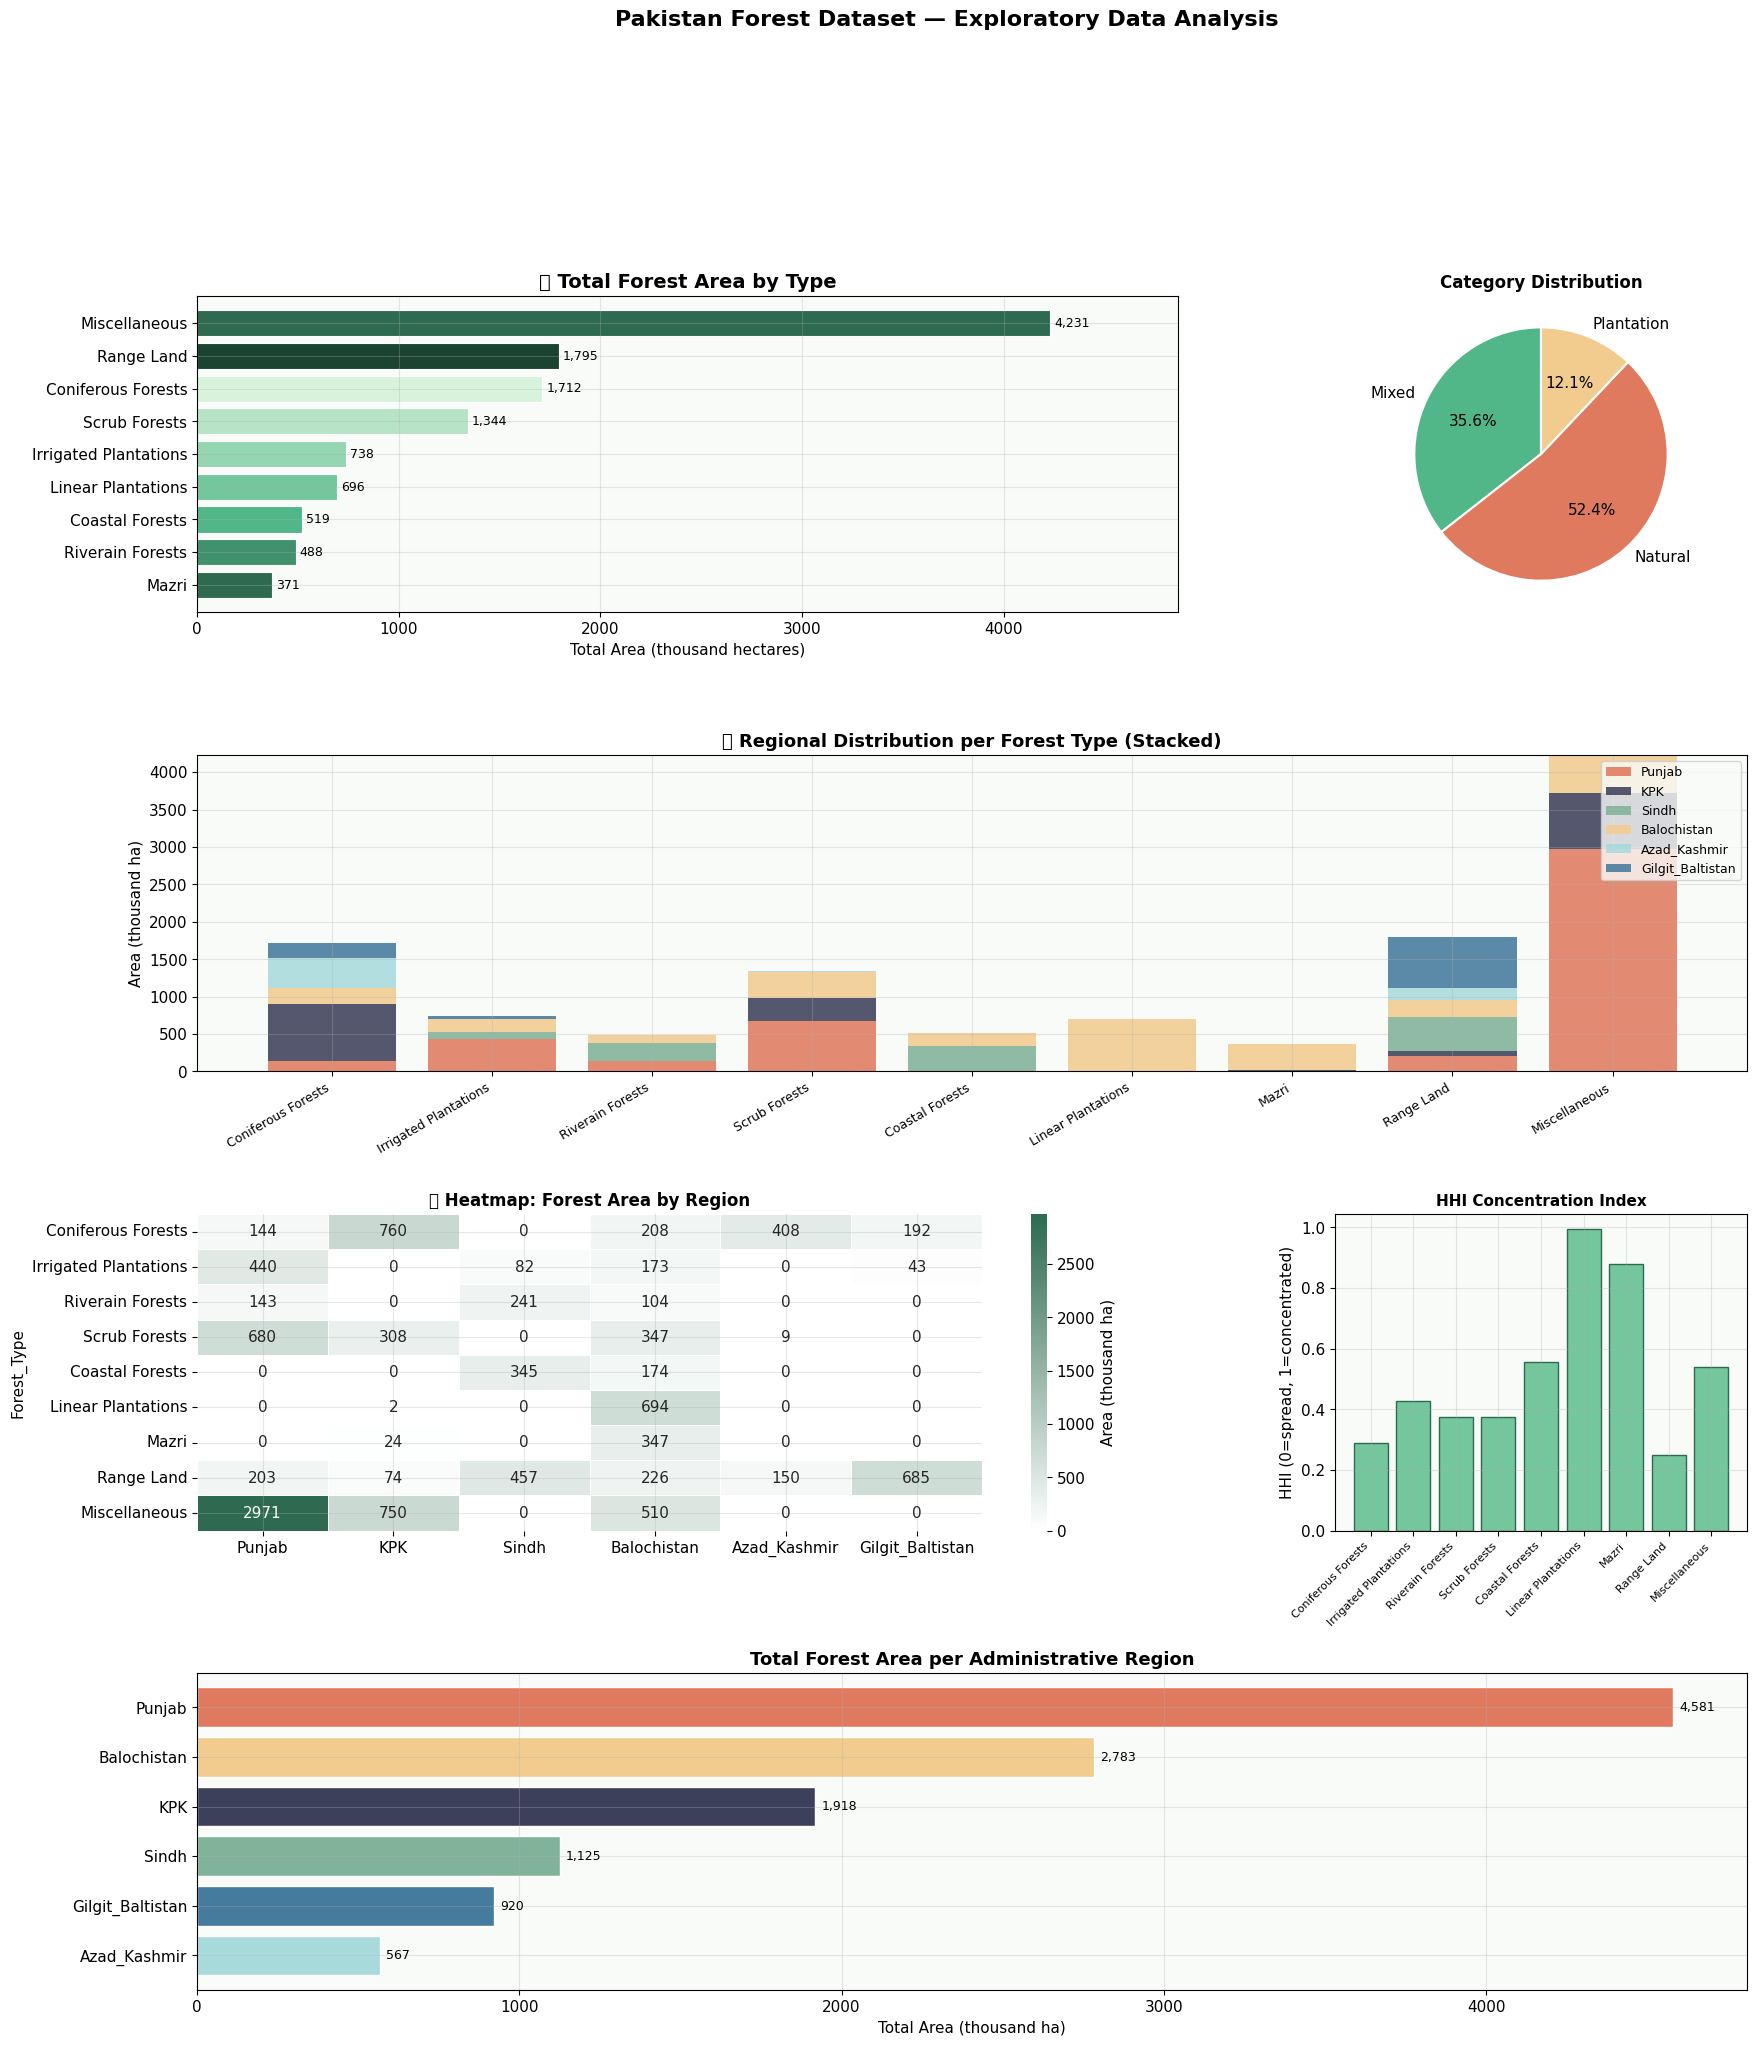

✅ EDA plots complete


In [4]:
fig = plt.figure(figsize=(20, 22))
gs  = GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.38)

# 3a: Total area by forest type (bar)
ax1 = fig.add_subplot(gs[0, :2])
forests = df[df['Forest_Type']!='Grand Total'].sort_values('Total', ascending=True)
bars = ax1.barh(forests['Forest_Type'], forests['Total'],
                color=FOREST_COLORS[:len(forests)], edgecolor='white', linewidth=0.8)
ax1.set_xlabel('Total Area (thousand hectares)')
ax1.set_title('📊 Total Forest Area by Type', fontsize=14, fontweight='bold')
for bar, val in zip(bars, forests['Total']):
    ax1.text(bar.get_width()+20, bar.get_y()+bar.get_height()/2,
             f'{int(val):,}', va='center', fontsize=9)
ax1.set_xlim(0, forests['Total'].max()*1.15)

# 3b: Pie of categories
ax2 = fig.add_subplot(gs[0, 2])
cat_totals = df.groupby('Type_Category')['Total'].sum()
ax2.pie(cat_totals, labels=cat_totals.index, autopct='%1.1f%%',
        colors=['#52B788','#E07A5F','#F2CC8F'], startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':1.5})
ax2.set_title('Category Distribution', fontsize=12, fontweight='bold')

# 3c: Stacked bar by region
ax3 = fig.add_subplot(gs[1, :])
bottom = np.zeros(len(df))
for i, reg in enumerate(region_cols):
    ax3.bar(df['Forest_Type'], df[reg], bottom=bottom,
            label=reg, color=REGION_COLORS[i], alpha=0.88)
    bottom += df[reg].values
ax3.set_ylabel('Area (thousand ha)')
ax3.set_title('🗺️ Regional Distribution per Forest Type (Stacked)', fontsize=13, fontweight='bold')
ax3.legend(loc='upper right', fontsize=9)
plt.setp(ax3.get_xticklabels(), rotation=30, ha='right', fontsize=9)

# 3d: Heatmap of region × forest
ax4 = fig.add_subplot(gs[2, :2])
heat = df.set_index('Forest_Type')[region_cols]
cmap_g = LinearSegmentedColormap.from_list('forest', ['#ffffff','#2D6A4F'])
sns.heatmap(heat, annot=True, fmt='.0f', cmap=cmap_g, ax=ax4,
            linewidths=0.5, linecolor='white', cbar_kws={'label':'Area (thousand ha)'})
ax4.set_title('🔥 Heatmap: Forest Area by Region', fontsize=12, fontweight='bold')
ax4.set_yticklabels(ax4.get_yticklabels(), rotation=0)

# 3e: HHI concentration
ax5 = fig.add_subplot(gs[2, 2])
ax5.bar(df['Forest_Type'], df['HHI'], color='#74C69D', edgecolor='#2D6A4F')
ax5.set_title('HHI Concentration Index', fontsize=11, fontweight='bold')
ax5.set_ylabel('HHI (0=spread, 1=concentrated)')
plt.setp(ax5.get_xticklabels(), rotation=45, ha='right', fontsize=8)

# 3f: Region totals
ax6 = fig.add_subplot(gs[3, :])
reg_totals = df[region_cols].sum().sort_values(ascending=True)
colors6 = [REGION_COLORS[region_cols.index(r)] for r in reg_totals.index]
ax6.barh(reg_totals.index, reg_totals.values, color=colors6, edgecolor='white')
ax6.set_title('Total Forest Area per Administrative Region', fontsize=13, fontweight='bold')
ax6.set_xlabel('Total Area (thousand ha)')
for i,(r,v) in enumerate(zip(reg_totals.index, reg_totals.values)):
    ax6.text(v+20, i, f'{int(v):,}', va='center', fontsize=9)

fig.suptitle('Pakistan Forest Dataset — Exploratory Data Analysis',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('eda.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ EDA plots complete")


## **4. Dataset Augmentation for ML (Bootstrap + Noise)**

This code implements a data augmentation strategy by generating 540 synthetic observations based on the original forest distribution patterns. It utilizes a Gaussian noise injection method to create realistic variations in regional area values while preserving the underlying ecological characteristics of each forest type. By recalculating complex metrics like the HHI and Gini coefficients for every new sample, the script produces a mathematically consistent and expanded dataset designed to enhance the robustness of downstream statistical modeling and machine learning tasks.

In [5]:
np.random.seed(42)
rows = []
for _, row in df.iterrows():
    for _ in range(60):          # 60 synthetic samples per forest type
        synthetic = {}
        synthetic['Forest_Type']     = row['Forest_Type']
        synthetic['Type_Category']   = row['Type_Category']
        synthetic['Type_Category_enc'] = row['Type_Category_enc']
        for reg in region_cols:
            base = row[reg]
            noise = np.random.normal(0, max(base*0.15, 5))
            synthetic[reg] = max(0, base + noise)
        synthetic['Total']           = sum(synthetic[r] for r in region_cols)
        r_vals = np.array([synthetic[r] for r in region_cols])
        synthetic['Region_Count']    = int((r_vals > 0).sum())
        tot = float(r_vals.sum())
        synthetic['HHI']             = float(((r_vals/tot)**2).sum()) if tot>0 else 1.0
        synthetic['Gini_approx']     = float(1 - ((r_vals/tot)**2).sum()) if tot>0 else 0.0
        synthetic['Max_Region_Share']= float(r_vals.max()/r_vals.sum()) if r_vals.sum()>0 else 0
        rows.append(synthetic)

aug = pd.DataFrame(rows)
print(f"Augmented dataset: {aug.shape}")
print(aug.describe().round(1).to_string())


Augmented dataset: (540, 14)
       Type_Category_enc  Punjab     KPK  Sindh  Balochistan  Azad_Kashmir  Gilgit_Baltistan   Total  Region_Count    HHI  Gini_approx  Max_Region_Share
count              540.0   540.0   540.0  540.0        540.0         540.0             540.0   540.0         540.0  540.0        540.0             540.0
mean                 1.1   508.4   209.6  127.2        310.4          63.8             106.0  1325.4           4.7    0.5          0.5               0.6
std                  0.6   899.3   301.9  171.4        188.3         130.2             220.7  1148.5           1.1    0.2          0.2               0.2
min                  0.0     0.0     0.0    0.0         69.7           0.0               0.0   257.6           1.0    0.2          0.0               0.3
25%                  1.0     3.4     2.1    0.0        174.6           0.0               0.0   525.8           4.0    0.3          0.4               0.5
50%                  1.0   154.7    24.1    5.8      

## **5. Principal Component Analysis (PCA)**

This script applies Principal Component Analysis to the augmented dataset to reduce the complexity of multiple regional variables into primary axes of variance. By generating a scree plot, a 2D category projection, and a biplot of feature loadings, the code visualizes how different forest types cluster and which specific factors—like HHI or regional dominance—drive those patterns. This multidimensional approach allows for the identification of underlying structural relationships between forest categories that are not immediately apparent in raw statistical tables.

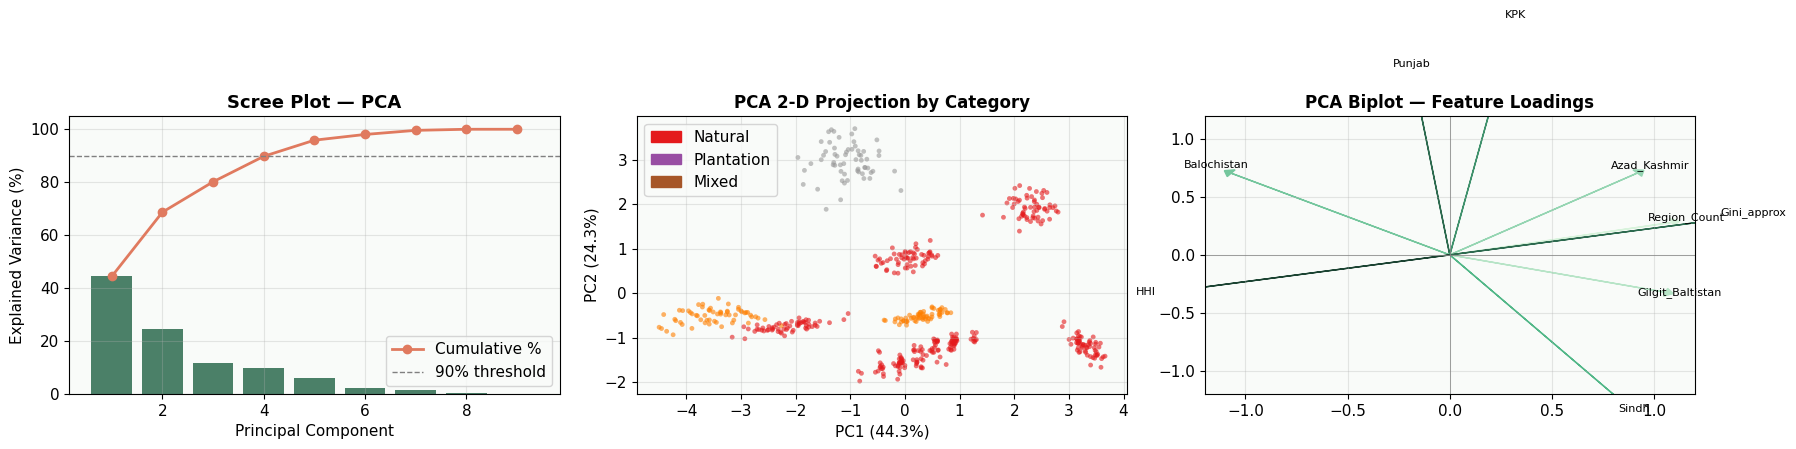

PC1+PC2 explain 68.6% of variance


In [6]:
features_pca = region_cols + ['Region_Count','HHI','Gini_approx']
X_pca_raw = aug[features_pca].values
scaler_pca = StandardScaler()
X_pca_sc   = scaler_pca.fit_transform(X_pca_raw)

pca = PCA()
pca.fit(X_pca_sc)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scree plot
ev_ratio = pca.explained_variance_ratio_
axes[0].bar(range(1, len(ev_ratio)+1), ev_ratio*100, color=FOREST_COLORS[0], alpha=0.85)
axes[0].plot(range(1, len(ev_ratio)+1), np.cumsum(ev_ratio)*100,
             'o-', color='#E07A5F', lw=2, ms=6, label='Cumulative %')
axes[0].axhline(90, ls='--', color='gray', lw=1, label='90% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot — PCA', fontsize=13, fontweight='bold')
axes[0].legend()

# 2-D scatter
pca2 = PCA(n_components=2)
X2d  = pca2.fit_transform(X_pca_sc)
cat_map = {'Natural':0,'Plantation':1,'Mixed':2}
c_idx   = aug['Type_Category'].map(cat_map).values
sc = axes[1].scatter(X2d[:,0], X2d[:,1], c=c_idx,
                     cmap='Set1', s=12, alpha=0.6, edgecolors='none')
axes[1].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('PCA 2-D Projection by Category', fontsize=12, fontweight='bold')
patches = [mpatches.Patch(color=plt.cm.Set1(v/3), label=k) for k,v in cat_map.items()]
axes[1].legend(handles=patches)

# Biplot loadings
components = pca2.components_
for i, feat in enumerate(features_pca):
    axes[2].arrow(0,0, components[0,i]*3, components[1,i]*3,
                  head_width=0.07, head_length=0.04,
                  fc=FOREST_COLORS[i % len(FOREST_COLORS)],
                  ec=FOREST_COLORS[i % len(FOREST_COLORS)])
    axes[2].text(components[0,i]*3.2, components[1,i]*3.2,
                 feat, fontsize=8, ha='center')
axes[2].set_xlim(-1.2,1.2); axes[2].set_ylim(-1.2,1.2)
axes[2].set_title('PCA Biplot — Feature Loadings', fontsize=12, fontweight='bold')
axes[2].axhline(0, color='gray', lw=0.5); axes[2].axvline(0, color='gray', lw=0.5)

plt.tight_layout()
plt.savefig('pca.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"PC1+PC2 explain {pca2.explained_variance_ratio_.sum()*100:.1f}% of variance")


## **6. Clustering Analysis (K-Means · Hierarchical · DBSCAN · Spectral)**

This code executes a suite of unsupervised machine learning techniques to identify natural groupings and structural relationships within the forest dataset across reduced principal components. By evaluating K-Means performance via Elbow curves and Silhouette scores, it determines the optimal number of clusters while simultaneously employing DBSCAN and Spectral Clustering to detect density-based patterns and noise. Furthermore, it incorporates hierarchical dendrograms to visualize the mathematical similarity between forest types, culminating in a multi-perspective dashboard that validates the dataset’s inherent categorical structure.

Best K = 6, Silhouette = 0.680


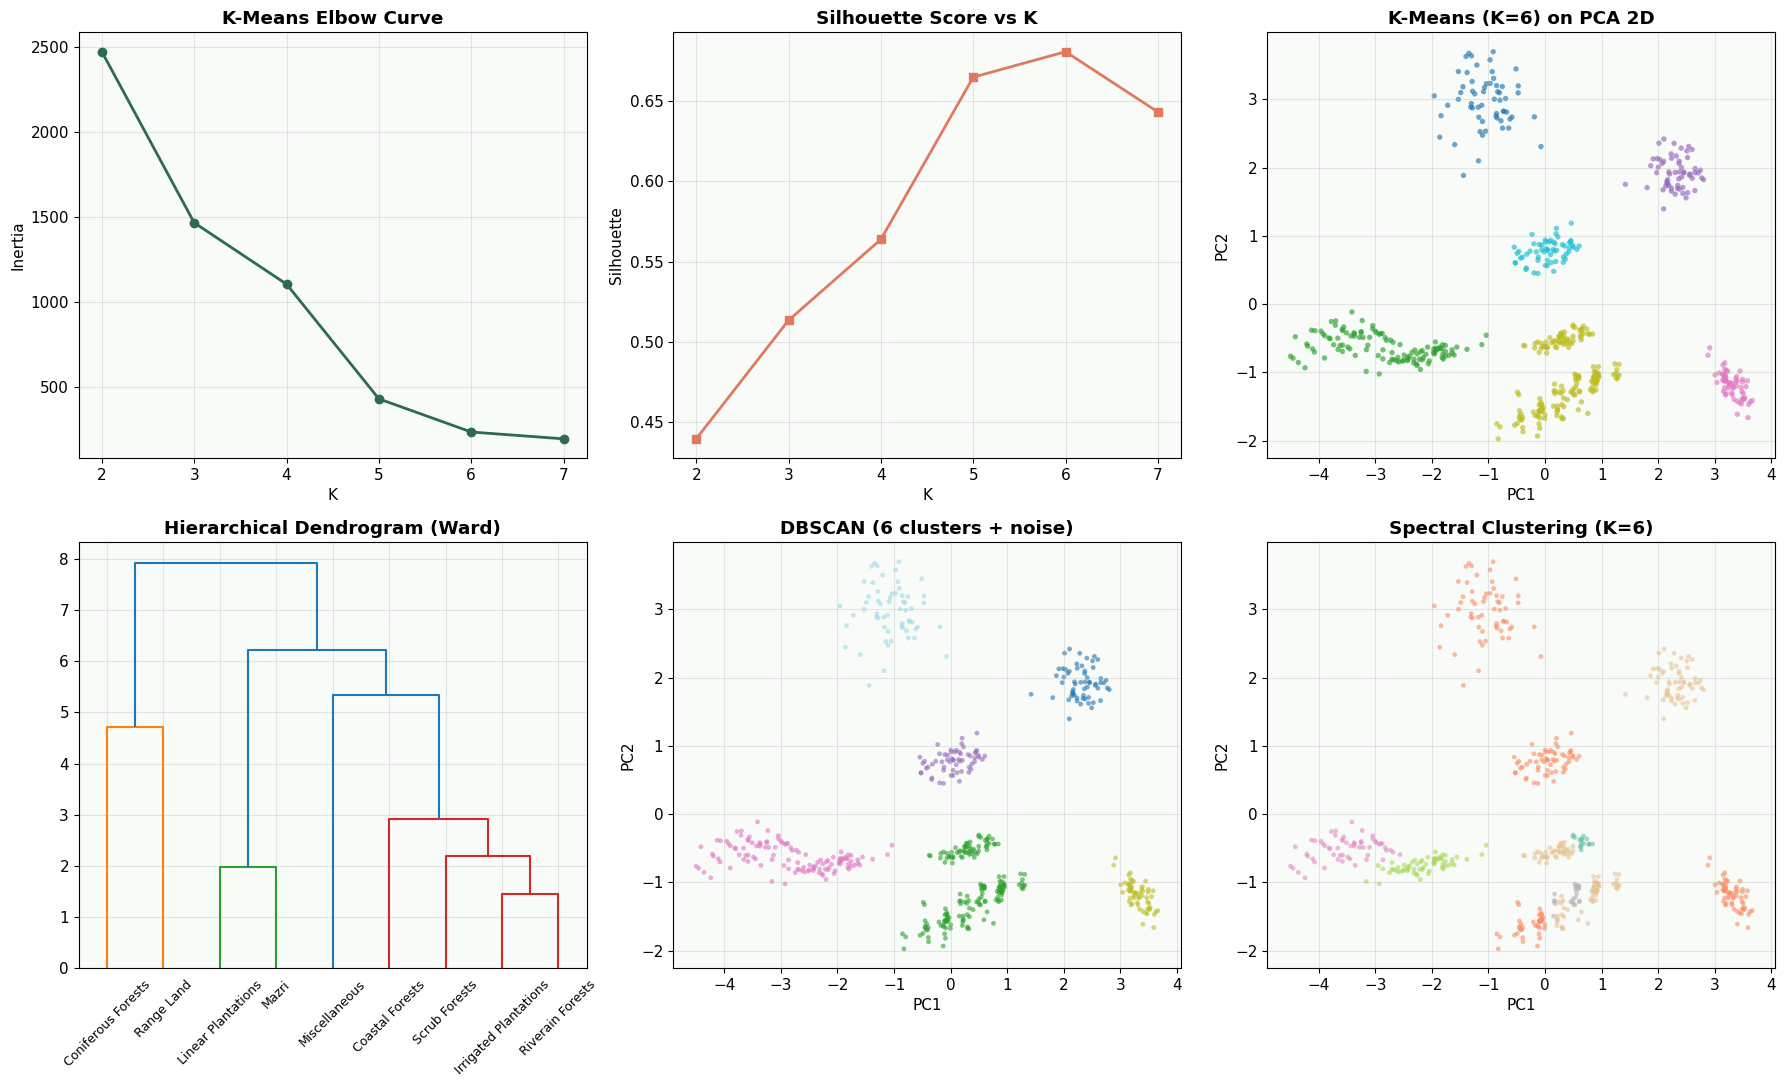

In [ ]:
pca3 = PCA(n_components=3)
X3d  = pca3.fit_transform(X_pca_sc)
# ── Elbow + Silhouette for K-Means ──
inertias, silhs = [], []
ks = range(2,8)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    lbl = km.fit_predict(X3d)
    inertias.append(km.inertia_)
    silhs.append(silhouette_score(X3d, lbl))

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Elbow
axes[0,0].plot(ks, inertias, 'o-', color=FOREST_COLORS[0], lw=2)
axes[0,0].set_title('K-Means Elbow Curve', fontweight='bold')
axes[0,0].set_xlabel('K'); axes[0,0].set_ylabel('Inertia')

# Silhouette
axes[0,1].plot(ks, silhs, 's-', color='#E07A5F', lw=2)
axes[0,1].set_title('Silhouette Score vs K', fontweight='bold')
axes[0,1].set_xlabel('K'); axes[0,1].set_ylabel('Silhouette')
best_k = ks[np.argmax(silhs)]
print(f"Best K = {best_k}, Silhouette = {max(silhs):.3f}")

# K-Means scatter (best_k)
km_best = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
km_labels = km_best.fit_predict(X3d)
axes[0,2].scatter(X2d[:,0], X2d[:,1], c=km_labels,
                  cmap='tab10', s=15, alpha=0.65, edgecolors='none')
axes[0,2].set_title(f'K-Means (K={best_k}) on PCA 2D', fontweight='bold')
axes[0,2].set_xlabel('PC1'); axes[0,2].set_ylabel('PC2')

# Hierarchical dendrogram (on original 9 forest types)
Z = linkage(scaler_pca.transform(df[features_pca].values), method='ward')
dendrogram(Z, labels=df['Forest_Type'].tolist(),
           leaf_rotation=45, leaf_font_size=9, ax=axes[1,0],
           color_threshold=Z[-3,2])
axes[1,0].set_title('Hierarchical Dendrogram (Ward)', fontweight='bold')

# DBSCAN
db = DBSCAN(eps=0.8, min_samples=5)
db_labels = db.fit_predict(X3d)
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
axes[1,1].scatter(X2d[:,0], X2d[:,1], c=db_labels,
                  cmap='tab20', s=12, alpha=0.6, edgecolors='none')
axes[1,1].set_title(f'DBSCAN ({n_clusters} clusters + noise)', fontweight='bold')
axes[1,1].set_xlabel('PC1'); axes[1,1].set_ylabel('PC2')

# Spectral
spec = SpectralClustering(n_clusters=best_k, affinity='nearest_neighbors', random_state=42)
spec_labels = spec.fit_predict(X3d)
axes[1,2].scatter(X2d[:,0], X2d[:,1], c=spec_labels,
                  cmap='Set2', s=12, alpha=0.6, edgecolors='none')
axes[1,2].set_title(f'Spectral Clustering (K={best_k})', fontweight='bold')
axes[1,2].set_xlabel('PC1'); axes[1,2].set_ylabel('PC2')

plt.tight_layout()
plt.savefig('clustering.png', dpi=130, bbox_inches='tight')
plt.show()


## **7. Regression Models — Predicting Total Forest Area (10 Regressors)**

This script executes a comparative analysis across eighteen distinct regression algorithms, utilizing automated scaling and cross-validation to identify the most accurate predictive model for forest area. By evaluating performance through $R^2$, RMSE, and MAE metrics, the pipeline generates a competitive leaderboard to highlight the superior efficiency of ensemble methods like Random Forest or XGBoost. The final stage provides diagnostic visualizations, including actual-versus-predicted plots and residual histograms, to ensure the chosen model maintains high reliability and minimal systematic bias.

                  Model       R²         RMSE          MAE
      Linear Regression 1.000000 5.270874e-13 4.000092e-13
        Huber Regressor 1.000000 9.932877e-10 8.965839e-10
Poly Regression (deg=2) 1.000000 1.659187e-12 1.306346e-12
       Lasso Regression 1.000000 3.726360e-01 2.910155e-01
       Ridge Regression 0.999989 3.988132e+00 2.514686e+00
            Extra Trees 0.998813 4.123461e+01 2.571325e+01
      XGBoost Regressor 0.998585 4.503282e+01 2.839969e+01
          Random Forest 0.997897 5.488901e+01 3.467447e+01
      Bagging Regressor 0.997831 5.574298e+01 3.589075e+01
             ElasticNet 0.997770 5.653088e+01 3.637124e+01
      Gradient Boosting 0.997458 6.035068e+01 4.474392e+01
          MLP Regressor 0.995688 7.860077e+01 5.456996e+01
     LightGBM Regressor 0.994937 8.517152e+01 4.759527e+01
          Decision Tree 0.993604 9.572907e+01 6.509554e+01
          KNN Regressor 0.993533 9.626163e+01 6.474968e+01
               AdaBoost 0.987973 1.312693e+02 1.066242e+

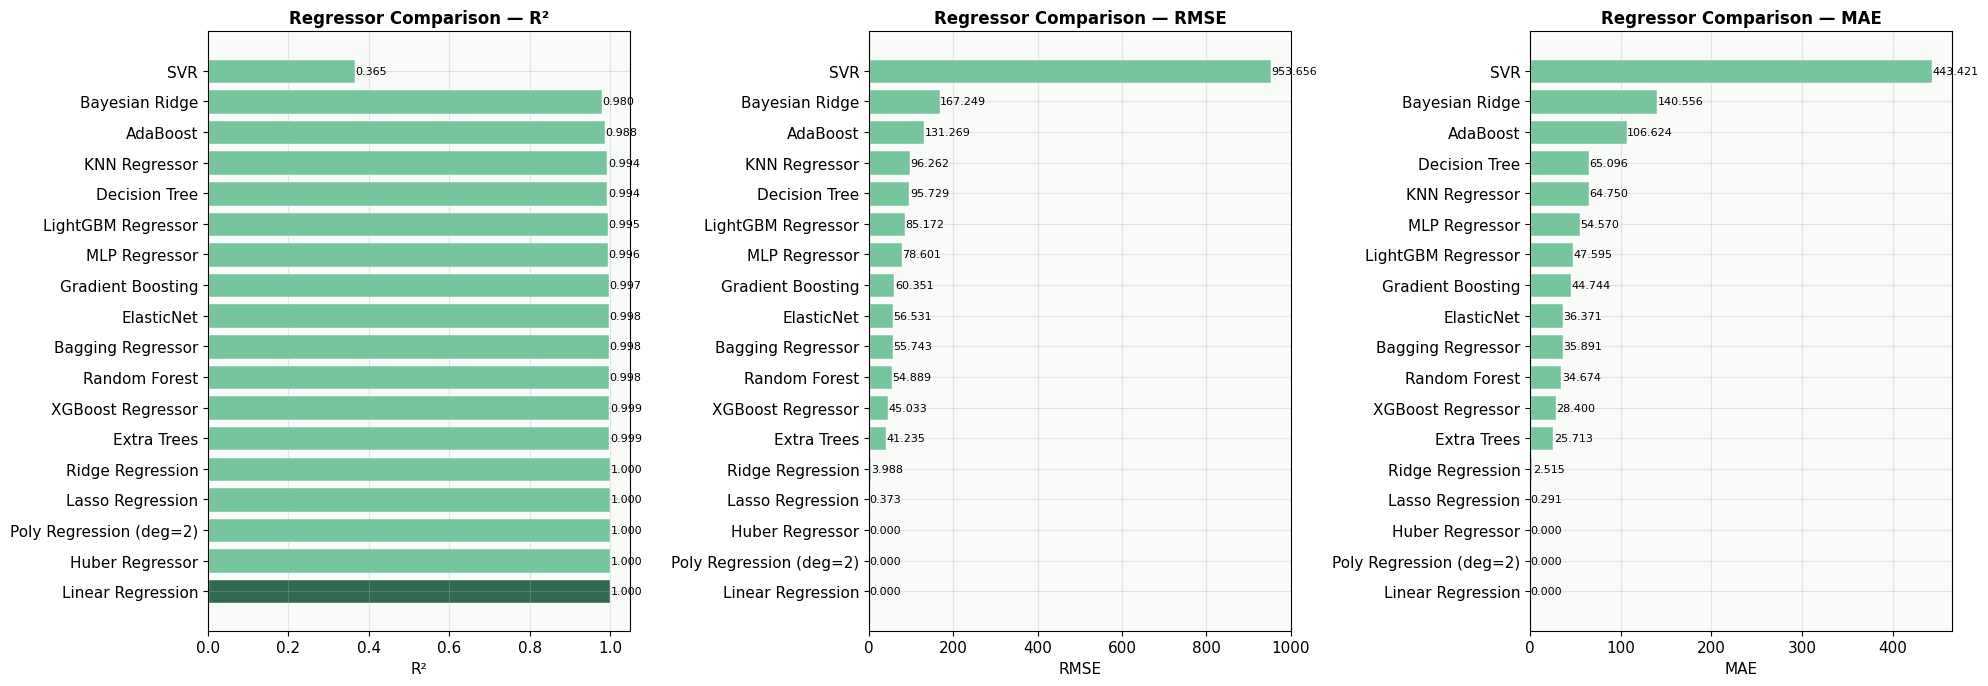

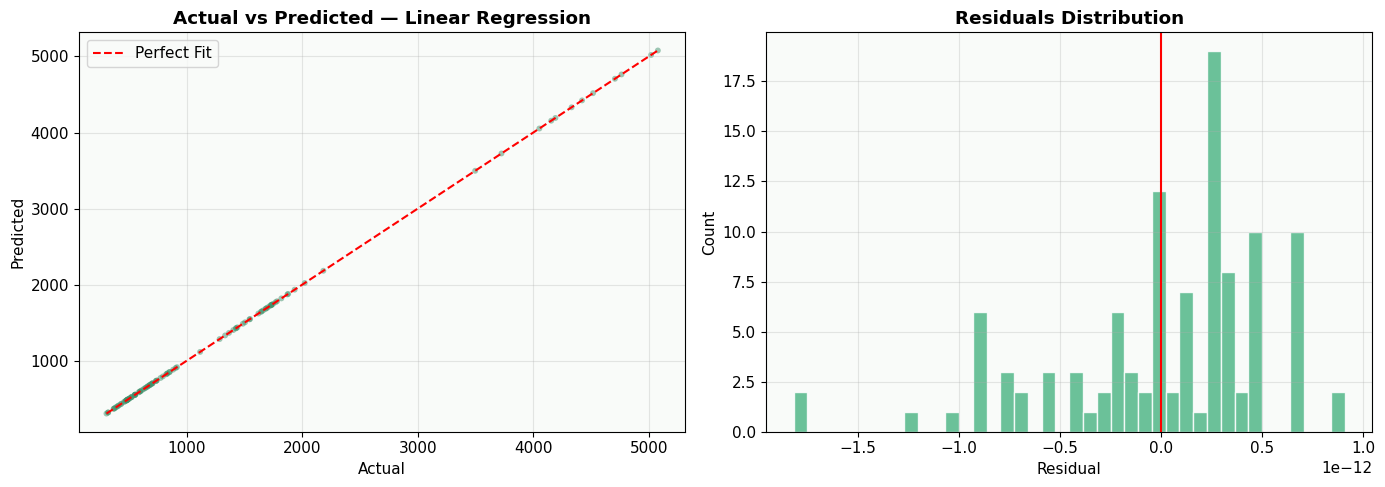

Best Regressor: Linear Regression  R²=1.0000


In [10]:
feat_reg  = region_cols + ['Region_Count','HHI','Gini_approx','Max_Region_Share']
X_reg     = aug[feat_reg].values
y_reg     = aug['Total'].values

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_reg, y_reg,
                                                test_size=0.2, random_state=42)
sc_reg = StandardScaler()
Xr_tr_sc = sc_reg.fit_transform(Xr_tr)
Xr_te_sc = sc_reg.transform(Xr_te)

regressors = {
    'Linear Regression'        : LinearRegression(),
    'Ridge Regression'         : Ridge(alpha=1.0),
    'Lasso Regression'         : Lasso(alpha=0.1),
    'ElasticNet'               : ElasticNet(alpha=0.1, l1_ratio=0.5),
    'Decision Tree'            : DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest'            : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'        : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'AdaBoost'                 : AdaBoostRegressor(n_estimators=80, random_state=42),
    'Extra Trees'              : ExtraTreesRegressor(n_estimators=100, random_state=42),
    'KNN Regressor'            : KNeighborsRegressor(n_neighbors=5),
    'SVR'                      : SVR(C=10, kernel='rbf'),
    'MLP Regressor'            : MLPRegressor(hidden_layer_sizes=(128,64),
                                              max_iter=500, random_state=42),
    'Bayesian Ridge'           : BayesianRidge(),
    'Huber Regressor'          : HuberRegressor(max_iter=300),
    'XGBoost Regressor'        : xgb.XGBRegressor(n_estimators=100, random_state=42,
                                                   verbosity=0),
    'LightGBM Regressor'       : lgb.LGBMRegressor(n_estimators=100, random_state=42,
                                                    verbose=-1),
    'Bagging Regressor'        : BaggingRegressor(n_estimators=50, random_state=42),
    'Poly Regression (deg=2)'  : Pipeline([('poly', PolynomialFeatures(2)),
                                           ('lr',   LinearRegression())]),
}

reg_results = []
for name, model in regressors.items():
    X_tr_use = Xr_tr_sc if name in ['Linear Regression','Ridge Regression',
                                      'Lasso Regression','ElasticNet',
                                      'SVR','MLP Regressor','Bayesian Ridge',
                                      'Huber Regressor','KNN Regressor',
                                      'Poly Regression (deg=2)'] else Xr_tr
    X_te_use = Xr_te_sc if name in ['Linear Regression','Ridge Regression',
                                      'Lasso Regression','ElasticNet',
                                      'SVR','MLP Regressor','Bayesian Ridge',
                                      'Huber Regressor','KNN Regressor',
                                      'Poly Regression (deg=2)'] else Xr_te
    model.fit(X_tr_use, yr_tr)
    preds = model.predict(X_te_use)
    r2  = r2_score(yr_te, preds)
    rmse= np.sqrt(mean_squared_error(yr_te, preds))
    mae = mean_absolute_error(yr_te, preds)
    reg_results.append({'Model':name, 'R²':r2, 'RMSE':rmse, 'MAE':mae})

reg_df = pd.DataFrame(reg_results).sort_values('R²', ascending=False)
print(reg_df.to_string(index=False))

# ── Visualise Regressor Leaderboard ──
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
colors_r = ['#2D6A4F' if i==0 else '#74C69D' for i in range(len(reg_df))]

for ax, metric in zip(axes, ['R²','RMSE','MAE']):
    sorted_df = reg_df.sort_values(metric, ascending=(metric != 'R²'))
    bars = ax.barh(sorted_df['Model'], sorted_df[metric],
                   color=colors_r, edgecolor='white')
    ax.set_title(f'Regressor Comparison — {metric}', fontweight='bold', fontsize=12)
    ax.set_xlabel(metric)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(bar.get_width()+0.001*max(sorted_df[metric]),
                bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('regressors.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Actual vs Predicted scatter for best model ──
best_reg_name = reg_df.iloc[0]['Model']
best_reg      = regressors[best_reg_name]
X_te_use_best = Xr_te_sc if best_reg_name in ['Linear Regression','Ridge Regression',
    'Lasso Regression','ElasticNet','SVR','MLP Regressor','Bayesian Ridge',
    'Huber Regressor','KNN Regressor','Poly Regression (deg=2)'] else Xr_te
preds_best = best_reg.predict(X_te_use_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(yr_te, preds_best, alpha=0.5, color='#40916C', edgecolors='none', s=18)
mn, mx = min(yr_te.min(), preds_best.min()), max(yr_te.max(), preds_best.max())
axes[0].plot([mn,mx],[mn,mx],'r--', lw=1.5, label='Perfect Fit')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Actual vs Predicted — {best_reg_name}', fontweight='bold')
axes[0].legend()

residuals = yr_te - preds_best
axes[1].hist(residuals, bins=40, color='#52B788', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', lw=1.5)
axes[1].set_title('Residuals Distribution', fontweight='bold')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('reg_actpred.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Best Regressor: {best_reg_name}  R²={reg_df.iloc[0]['R²']:.4f}")


## **8. Classification Models — Predicting Ecosystem Category (10 Classifiers)**

This script implements a comprehensive classification pipeline that evaluates thirteen diverse machine learning models to categorize forests into natural, plantation, or mixed types. By utilizing stratified splitting and standardized scaling for sensitive algorithms, the code ensures a rigorous comparison based on weighted F1-scores and accuracy metrics. The final output generates a performance leaderboard alongside a confusion matrix for the top-ranked classifier, providing a detailed diagnostic of the model’s ability to distinguish between distinct ecological classes.

              Model  Accuracy  F1-Weighted
      Decision Tree  1.000000     1.000000
      Random Forest  1.000000     1.000000
  Gradient Boosting  1.000000     1.000000
           AdaBoost  1.000000     1.000000
 Bagging Classifier  1.000000     1.000000
Logistic Regression  0.990741     0.990674
        Extra Trees  0.990741     0.990674
     KNN Classifier  0.990741     0.990674
          SVM (RBF)  0.990741     0.990674
     MLP Classifier  0.990741     0.990674
 XGBoost Classifier  0.990741     0.990674
LightGBM Classifier  0.990741     0.990674
        Naive Bayes  0.972222     0.972744


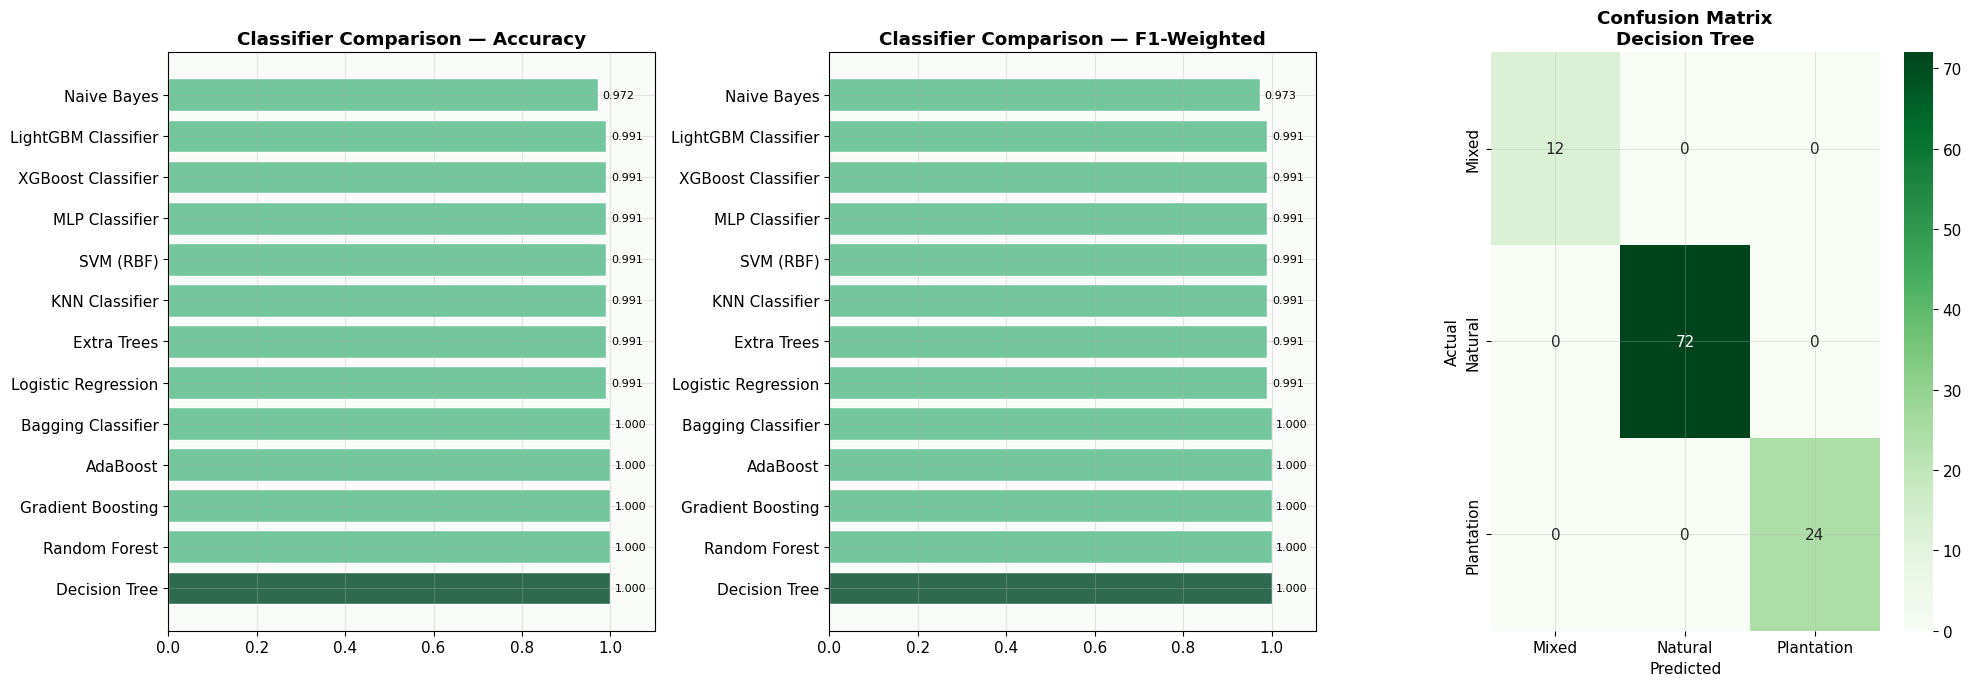

Best Classifier: Decision Tree  F1=1.0000


In [11]:
feat_clf = region_cols + ['Region_Count','HHI','Gini_approx','Max_Region_Share','Total']
X_clf    = aug[feat_clf].values
y_clf    = aug['Type_Category_enc'].values

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_clf, y_clf,
                                                test_size=0.2, random_state=42,
                                                stratify=y_clf)
sc_clf   = StandardScaler()
Xc_tr_sc = sc_clf.fit_transform(Xc_tr)
Xc_te_sc = sc_clf.transform(Xc_te)

classifiers = {
    'Logistic Regression'       : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'             : DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest'             : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'         : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost'                  : AdaBoostClassifier(n_estimators=80, random_state=42),
    'Extra Trees'               : ExtraTreesClassifier(n_estimators=100, random_state=42),
    'KNN Classifier'            : KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)'                 : SVC(C=5, kernel='rbf', probability=True, random_state=42),
    'Naive Bayes'               : GaussianNB(),
    'MLP Classifier'            : MLPClassifier(hidden_layer_sizes=(128,64),
                                                max_iter=500, random_state=42),
    'XGBoost Classifier'        : xgb.XGBClassifier(n_estimators=100, random_state=42,
                                                     verbosity=0, use_label_encoder=False,
                                                     eval_metric='mlogloss'),
    'LightGBM Classifier'       : lgb.LGBMClassifier(n_estimators=100, random_state=42,
                                                      verbose=-1),
    'Bagging Classifier'        : BaggingClassifier(n_estimators=50, random_state=42),
}

NEEDS_SCALE_CLF = {'Logistic Regression','KNN Classifier','SVM (RBF)','MLP Classifier'}
clf_results = []
best_clf_model, best_f1, best_clf_name = None, -1, ''

for name, model in classifiers.items():
    Xtr = Xc_tr_sc if name in NEEDS_SCALE_CLF else Xc_tr
    Xte = Xc_te_sc if name in NEEDS_SCALE_CLF else Xc_te
    model.fit(Xtr, yc_tr)
    preds = model.predict(Xte)
    acc   = accuracy_score(yc_te, preds)
    f1    = f1_score(yc_te, preds, average='weighted')
    clf_results.append({'Model':name, 'Accuracy':acc, 'F1-Weighted':f1})
    if f1 > best_f1:
        best_f1 = f1; best_clf_model = model; best_clf_name = name

clf_df = pd.DataFrame(clf_results).sort_values('F1-Weighted', ascending=False)
print(clf_df.to_string(index=False))

# ── Classifier Leaderboard + Confusion Matrix ──
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
colors_c = ['#2D6A4F' if i==0 else '#74C69D' for i in range(len(clf_df))]

for ax, metric in zip(axes[:2], ['Accuracy','F1-Weighted']):
    sdf = clf_df.sort_values(metric, ascending=False)
    bars = ax.barh(sdf['Model'], sdf[metric], color=colors_c, edgecolor='white')
    ax.set_xlim(0, 1.1)
    ax.set_title(f'Classifier Comparison — {metric}', fontweight='bold')
    for bar, val in zip(bars, sdf[metric]):
        ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

# Confusion matrix for best classifier
best_Xte = Xc_te_sc if best_clf_name in NEEDS_SCALE_CLF else Xc_te
cm = confusion_matrix(yc_te, best_clf_model.predict(best_Xte))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[2],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[2].set_title('Confusion Matrix\n' + best_clf_name, fontweight='bold')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('classifiers.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Best Classifier: {best_clf_name}  F1={best_f1:.4f}")


## **9. Deep Learning with PyTorch — Forest Area Regression Network**

This script constructs and trains "ForestNet," a custom PyTorch deep learning model that utilizes a residual architecture with skip connections, Batch Normalization, and Dropout to capture complex, non-linear relationships within the forest dataset. The training process employs the AdamW optimizer and Huber Loss over 200 epochs, using a Cosine Annealing scheduler to ensure stable convergence and high generalization performance. Finally, the model is evaluated using $R^2$ and RMSE metrics, supplemented by diagnostic visualizations of training loss curves and actual-versus-predicted regression plots to verify its predictive accuracy.

Using device: cpu
Epoch  50 | Train Loss: 169.96 | Val Loss: 87.57
Epoch 100 | Train Loss: 175.11 | Val Loss: 49.45
Epoch 150 | Train Loss: 178.85 | Val Loss: 73.76
Epoch 200 | Train Loss: 143.49 | Val Loss: 96.61

PyTorch Deep Model  R²=0.9790  RMSE=173.56


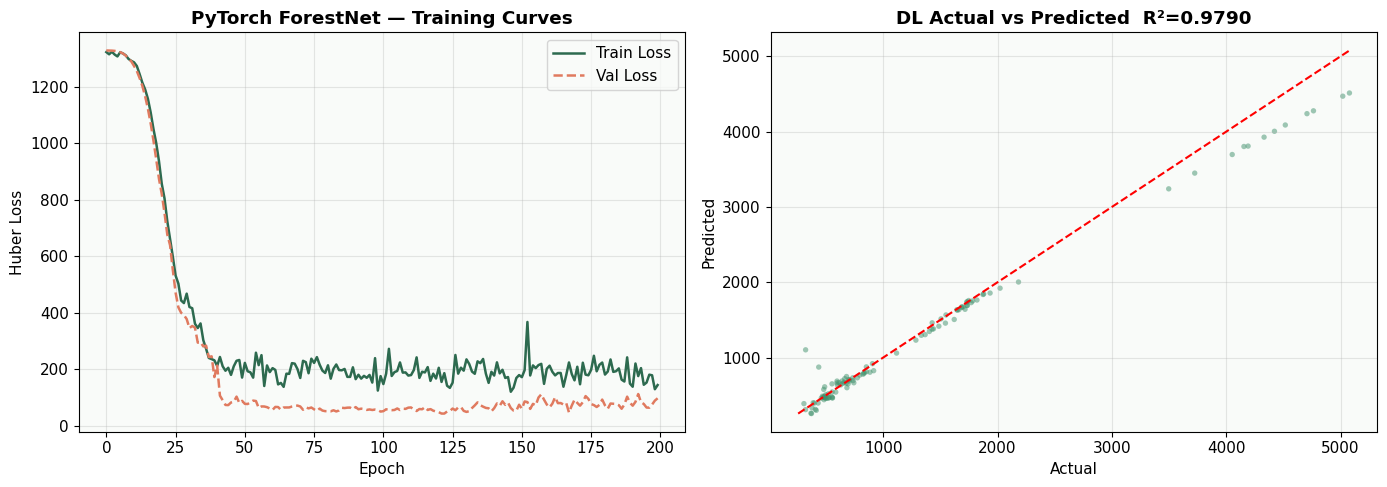

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ── Prepare tensors ──
X_dl = torch.tensor(Xr_tr_sc, dtype=torch.float32).to(device)
y_dl = torch.tensor(yr_tr.reshape(-1,1), dtype=torch.float32).to(device)
Xte_dl = torch.tensor(Xr_te_sc, dtype=torch.float32).to(device)
yte_dl  = torch.tensor(yr_te.reshape(-1,1), dtype=torch.float32).to(device)

ds = TensorDataset(X_dl, y_dl)
loader = DataLoader(ds, batch_size=64, shuffle=True)

# ── Architecture: Deep Residual MLP ──
class ForestNet(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.input_proj = nn.Linear(in_features, 128)
        self.block1 = nn.Sequential(nn.Linear(128,128), nn.ReLU(),
                                     nn.BatchNorm1d(128), nn.Dropout(0.2),
                                     nn.Linear(128,128))
        self.block2 = nn.Sequential(nn.Linear(128,64), nn.ReLU(),
                                     nn.BatchNorm1d(64), nn.Dropout(0.15),
                                     nn.Linear(64,64))
        self.head = nn.Sequential(nn.Linear(64,32), nn.ReLU(), nn.Linear(32,1))
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.input_proj(x))
        x = self.relu(x + self.block1(x))       # residual
        x = self.relu(self.block2(x))
        return self.head(x)

model_dl = ForestNet(X_dl.shape[1]).to(device)
optimizer = optim.AdamW(model_dl.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
loss_fn = nn.HuberLoss()

train_losses, val_losses = [], []
EPOCHS = 200

for epoch in range(1, EPOCHS+1):
    model_dl.train()
    ep_loss = []
    for xb, yb in loader:
        optimizer.zero_grad()
        pred = model_dl(xb)
        loss = loss_fn(pred, yb)
        loss.backward(); optimizer.step()
        ep_loss.append(loss.item())
    scheduler.step()
    train_losses.append(np.mean(ep_loss))
    
    model_dl.eval()
    with torch.no_grad():
        vp = model_dl(Xte_dl)
        vl = loss_fn(vp, yte_dl).item()
    val_losses.append(vl)

    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {train_losses[-1]:.2f} | Val Loss: {val_losses[-1]:.2f}")

# ── Evaluate ──
model_dl.eval()
with torch.no_grad():
    dl_preds = model_dl(Xte_dl).cpu().numpy().flatten()
dl_r2   = r2_score(yr_te, dl_preds)
dl_rmse = np.sqrt(mean_squared_error(yr_te, dl_preds))
print(f"\nPyTorch Deep Model  R²={dl_r2:.4f}  RMSE={dl_rmse:.2f}")

# ── DL Training Curves ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss', color=FOREST_COLORS[0], lw=1.8)
axes[0].plot(val_losses,   label='Val Loss',   color='#E07A5F', lw=1.8, ls='--')
axes[0].set_title('PyTorch ForestNet — Training Curves', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Huber Loss')
axes[0].legend()

axes[1].scatter(yr_te, dl_preds, alpha=0.5, color='#40916C', s=15, edgecolors='none')
mn2,mx2 = min(yr_te.min(),dl_preds.min()), max(yr_te.max(),dl_preds.max())
axes[1].plot([mn2,mx2],[mn2,mx2],'r--', lw=1.5)
axes[1].set_title(f'DL Actual vs Predicted  R²={dl_r2:.4f}', fontweight='bold')
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')

plt.tight_layout()
plt.savefig('dl_curves.png', dpi=130, bbox_inches='tight')
plt.show()


## **10. Natural Language Processing (NLP) on Forest Type Names & Descriptions**

This script processes descriptive text for each forest type by applying Natural Language Processing (NLP) techniques, including tokenization and stopword removal, to extract key ecological terms. It employs frequency analysis and TF-IDF vectorization to identify unique characteristics of specific habitats, such as "mangroves" for coastal regions versus "alpine" for coniferous forests. The resulting visualizations—including term heatmaps and a cosine similarity matrix—quantify the semantic relationships between different forest categories, revealing how closely related various ecosystems are based on their biological and geographical descriptions.

Top 20 terms across all forest types:
[('forests', 7), ('trees', 7), ('habitat', 3), ('wood', 3), ('along', 3), ('balochistan', 3), ('coniferous', 2), ('consist', 2), ('alpine', 2), ('snow', 2), ('timber', 2), ('plantations', 2), ('managed', 2), ('water', 2), ('irrigation', 2), ('plantation', 2), ('fuel', 2), ('canals', 2), ('grow', 2), ('plains', 2)]


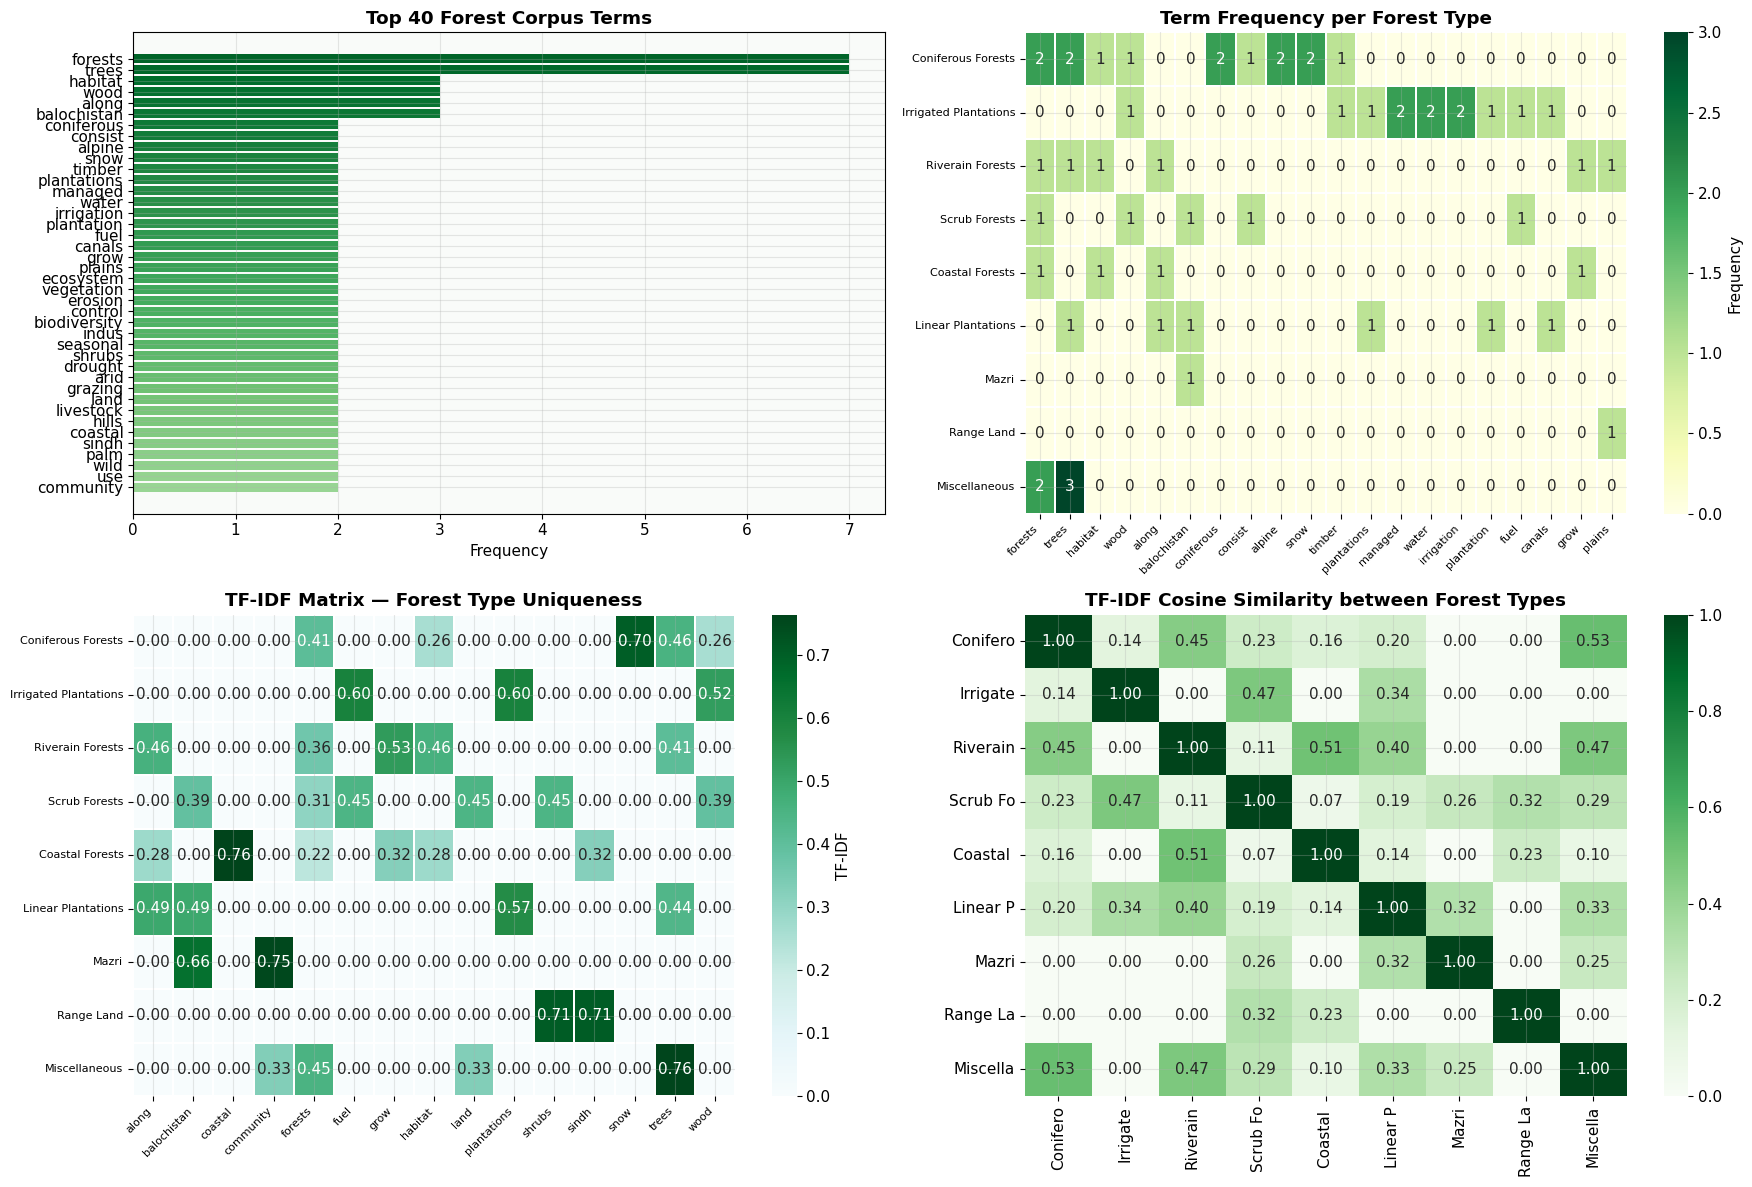

In [13]:
# ── NLP: Build textual corpus of forest descriptions ──
import re
from collections import Counter

# Robust stopwords (no NLTK dependency)
try:
    import nltk
    nltk.download('stopwords', quiet=True)
    from nltk.corpus import stopwords
    stop_words = set(stopwords.words('english'))
except Exception:
    stop_words = {
        'the','a','an','and','or','but','in','on','at','to','for',
        'of','with','by','from','as','is','are','was','were','be',
        'been','being','have','has','had','do','does','did','will',
        'would','could','should','may','might','its','it','this',
        'that','these','those'
    }

forest_descriptions = {
    'Coniferous Forests': ('Coniferous forests consist of evergreen pine cedar fir trees growing in '
        'mountainous alpine terrain. These forests provide vital habitat for diverse wildlife including '
        'snow leopard black bear and numerous bird species. Coniferous trees produce cones seeds resin '
        'timber wood. Alpine environment cold temperature high altitude precipitation snow.'),
    'Irrigated Plantations': ('Irrigated plantations are managed tree farms receiving artificial water '
        'irrigation. Plantation agriculture produces timber wood fuel commercial products economic value. '
        'Managed irrigation canals water resources Punjab agricultural zone.'),
    'Riverain Forests': ('Riverain forests grow along rivers floodplains alluvial plains. River ecosystem '
        'riparian vegetation flood protection soil erosion control biodiversity habitat. Shisham Acacia '
        'trees Indus floodplain seasonal flooding.'),
    'Scrub Forests': ('Scrub forests consist of low thorny shrubs bushes drought tolerant vegetation '
        'arid semi-arid regions. Fuel wood charcoal production grazing land livestock rangeland. '
        'Balochistan hills dry climate.'),
    'Coastal Forests': ('Coastal mangrove forests grow along tidal creeks brackish saltwater estuaries. '
        'Mangroves protect coastline storm surge fish breeding nursery habitat carbon sequestration. '
        'Sindh Indus Delta Arabian Sea coastal ecosystem.'),
    'Linear Plantations': ('Linear plantations are rows trees planted along roads canals railways '
        'shelterbelts. Windbreaks erosion control shade aesthetic landscape enhancement. Balochistan '
        'road network canal lining plantation programme.'),
    'Mazri': ('Mazri palm dwarf palm grows wild Balochistan hills. Indigenous traditional use basket '
        'weaving mat craft cultural heritage. Drought resistant wild plant community livelihood rural areas.'),
    'Range Land': ('Range lands are open grasslands pastures grazing livestock cattle sheep goat. '
        'Nomadic pastoral communities transhumance seasonal migration. Fodder grass herbs shrubs '
        'Gilgit Baltistan highland pastures Sindh plains.'),
    'Miscellaneous': ('Miscellaneous forest category includes farmlands trees orchards fruit trees '
        'community forests. Mixed land use agroforestry private trees urban peri-urban forests '
        'biodiversity conservation areas.')
}

def preprocess(text):
    tokens = re.findall(r'[a-z]+', text.lower())
    return [t for t in tokens if t not in stop_words and len(t) > 2]

all_tokens, per_type_tokens = [], {}
for ftype, desc in forest_descriptions.items():
    tokens = preprocess(desc)
    per_type_tokens[ftype] = tokens
    all_tokens.extend(tokens)

freq = Counter(all_tokens)
print("Top 20 terms across all forest types:")
print(freq.most_common(20))
# (Requires NLP corpus cell above to have run)

# ── NLP Visualisations ──
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Top-40 bar chart
top40 = freq.most_common(40)
words40, counts40 = zip(*top40)
axes[0,0].barh(list(words40[::-1]), list(counts40[::-1]),
               color=plt.cm.Greens(np.linspace(0.4,0.9,40)))
axes[0,0].set_title('Top 40 Forest Corpus Terms', fontweight='bold')
axes[0,0].set_xlabel('Frequency')

# Per-type top word heatmap
type_names = list(per_type_tokens.keys())
all_vocab = [w for w,_ in freq.most_common(20)]
heat_data = np.zeros((len(type_names), len(all_vocab)))
for i, ft in enumerate(type_names):
    tc = Counter(per_type_tokens[ft])
    for j, w in enumerate(all_vocab):
        heat_data[i,j] = tc.get(w,0)

sns.heatmap(heat_data, xticklabels=all_vocab, yticklabels=type_names,
            cmap='YlGn', annot=True, fmt='.0f', ax=axes[0,1],
            linewidths=0.3, cbar_kws={'label':'Frequency'})
axes[0,1].set_title('Term Frequency per Forest Type', fontweight='bold')
plt.setp(axes[0,1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(axes[0,1].get_yticklabels(), rotation=0, fontsize=8)

# TF-IDF style uniqueness
from sklearn.feature_extraction.text import TfidfVectorizer
corpus_list  = [' '.join(per_type_tokens[ft]) for ft in type_names]
tfidf = TfidfVectorizer(max_features=15)
tfidf_matrix = tfidf.fit_transform(corpus_list).toarray()
tfidf_df = pd.DataFrame(tfidf_matrix, index=type_names, columns=tfidf.get_feature_names_out())
sns.heatmap(tfidf_df, cmap='BuGn', ax=axes[1,0], annot=True, fmt='.2f',
            linewidths=0.3, cbar_kws={'label':'TF-IDF'})
axes[1,0].set_title('TF-IDF Matrix — Forest Type Uniqueness', fontweight='bold')
plt.setp(axes[1,0].get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(axes[1,0].get_yticklabels(), rotation=0, fontsize=8)

# Cosine similarity between forest types
from sklearn.metrics.pairwise import cosine_similarity
cos_sim = cosine_similarity(tfidf_matrix)
sns.heatmap(cos_sim, xticklabels=[t[:8] for t in type_names],
            yticklabels=[t[:8] for t in type_names],
            cmap='Greens', annot=True, fmt='.2f', ax=axes[1,1])
axes[1,1].set_title('TF-IDF Cosine Similarity between Forest Types', fontweight='bold')

plt.tight_layout()
plt.savefig('nlp.png', dpi=130, bbox_inches='tight')
plt.show()


## **11. Future Forecasting — 5 to 10 Year Projections (2025–2035)**

This code simulates the future trajectory of Pakistan’s forest cover from 2025 to 2035 by applying scenario-based growth and decline rates to the established baseline data. It generates comprehensive visualizations, including multi-panel time-series plots for individual forest types and aggregated national forecasts that highlight potential cumulative changes under optimistic, business-as-usual, and pessimistic conditions. By incorporating uncertainty bands and milestone markers, the script provides a robust statistical outlook and a summary table to assist in long-term environmental planning and sustainability target assessment

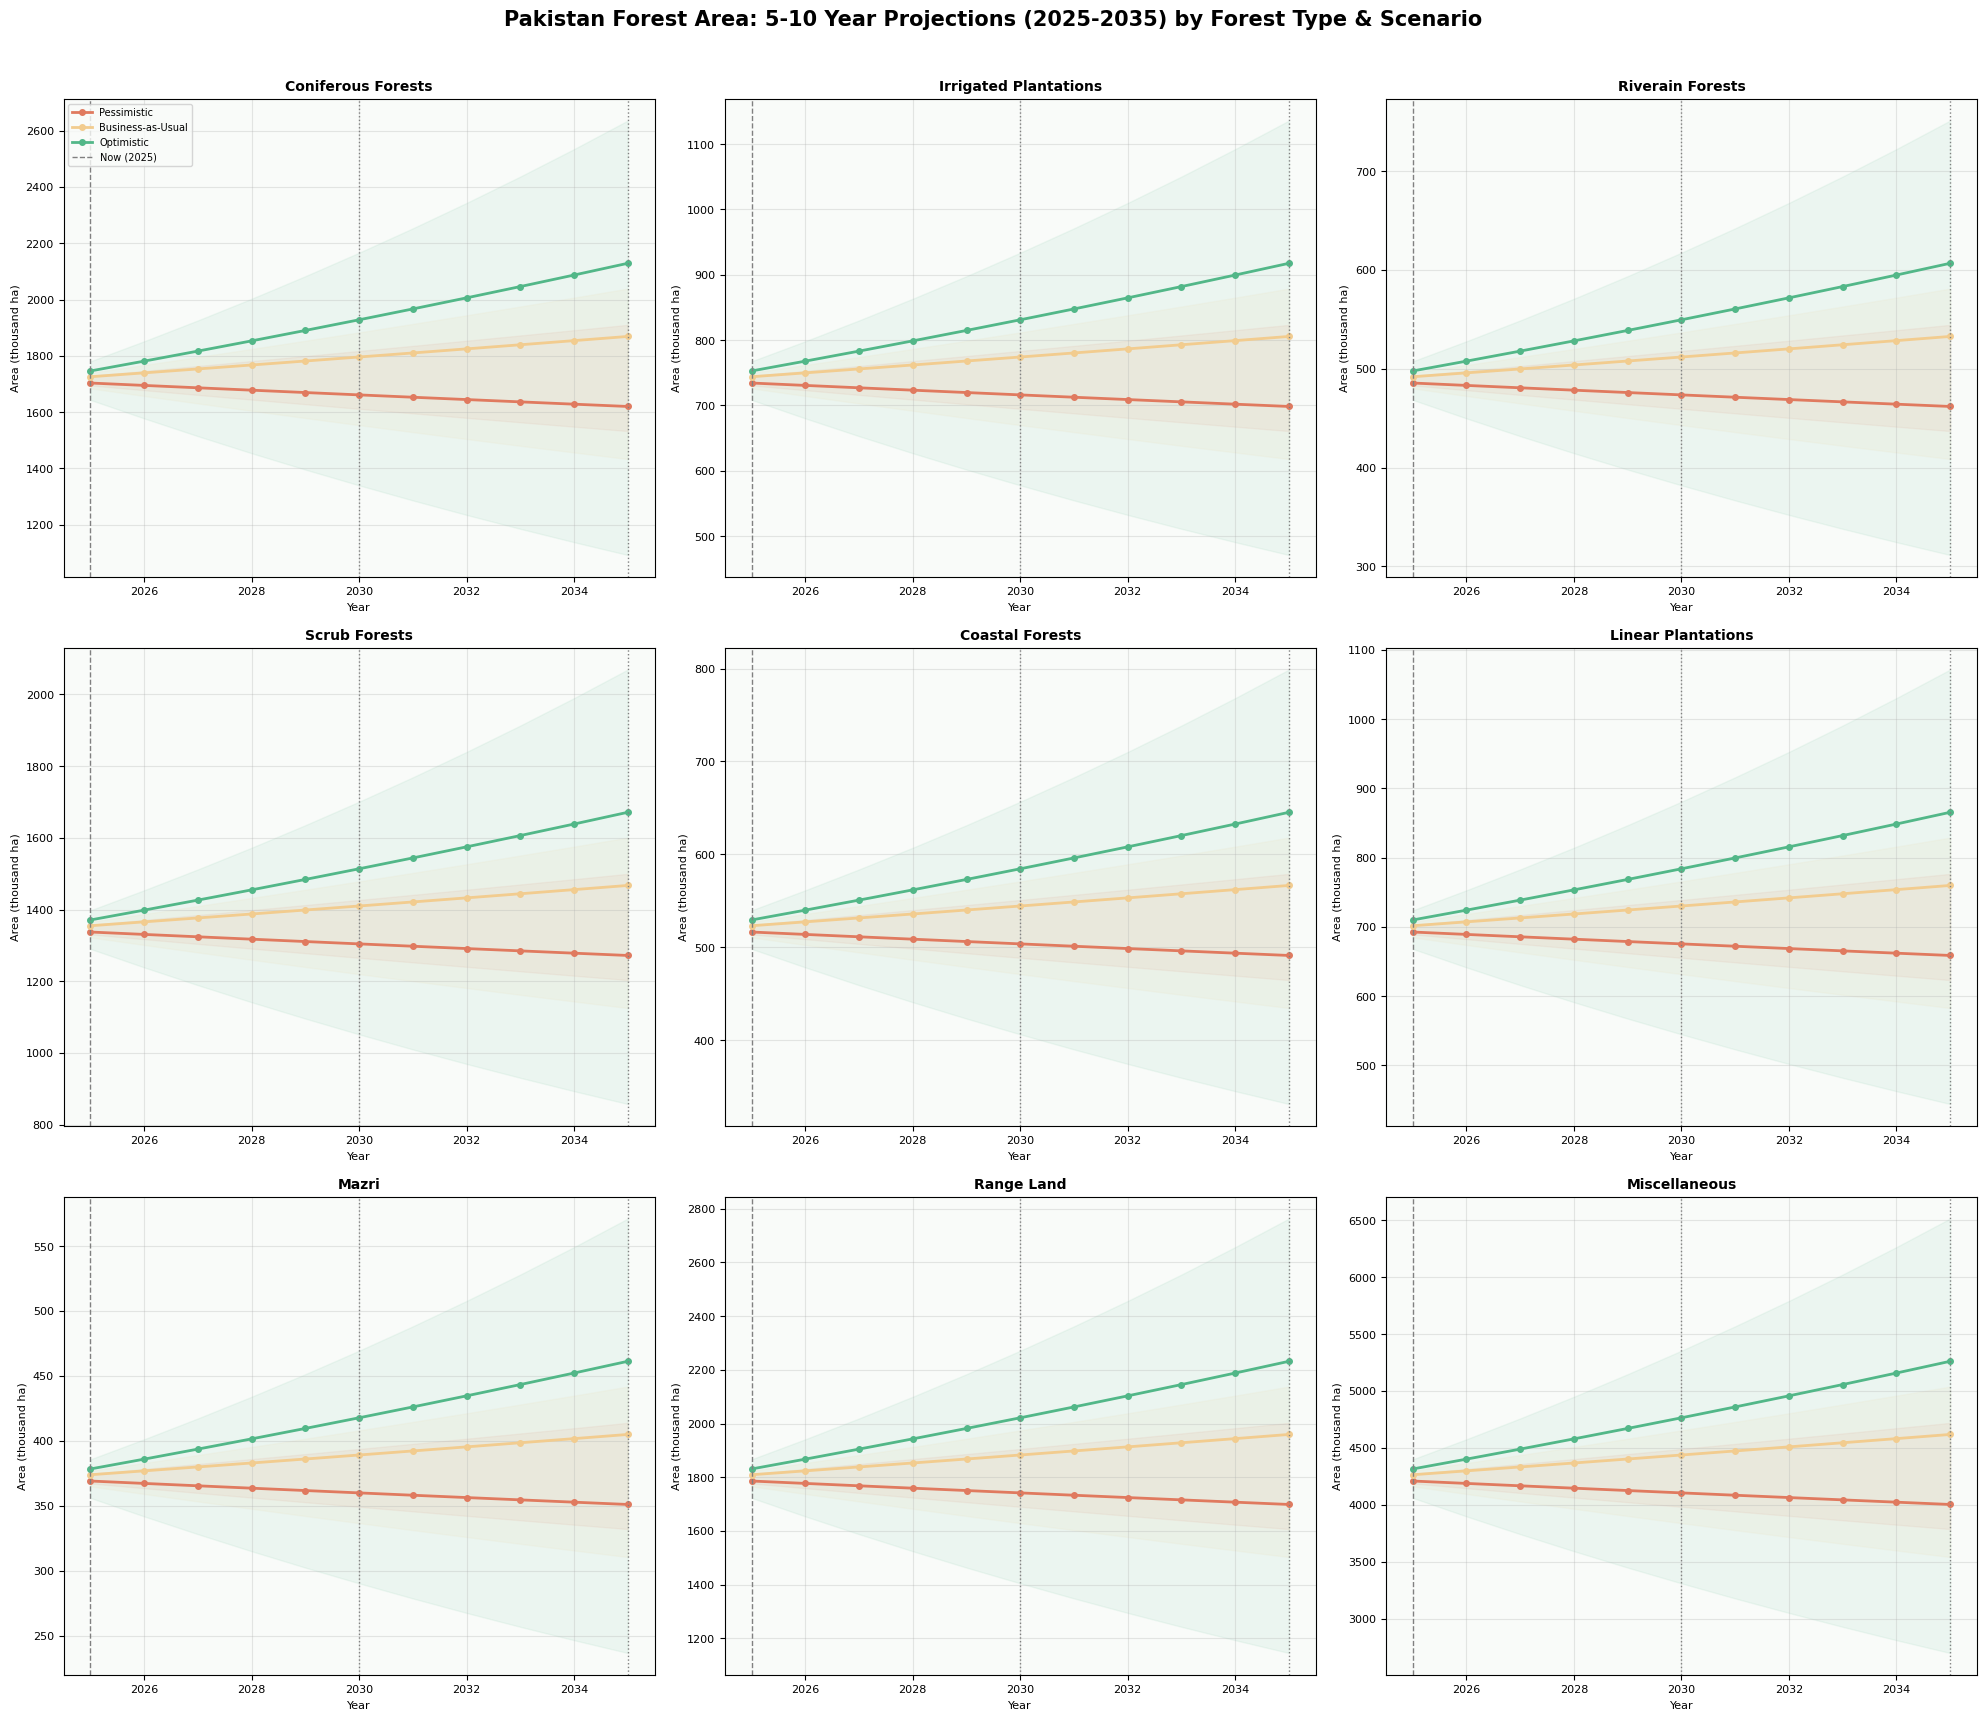

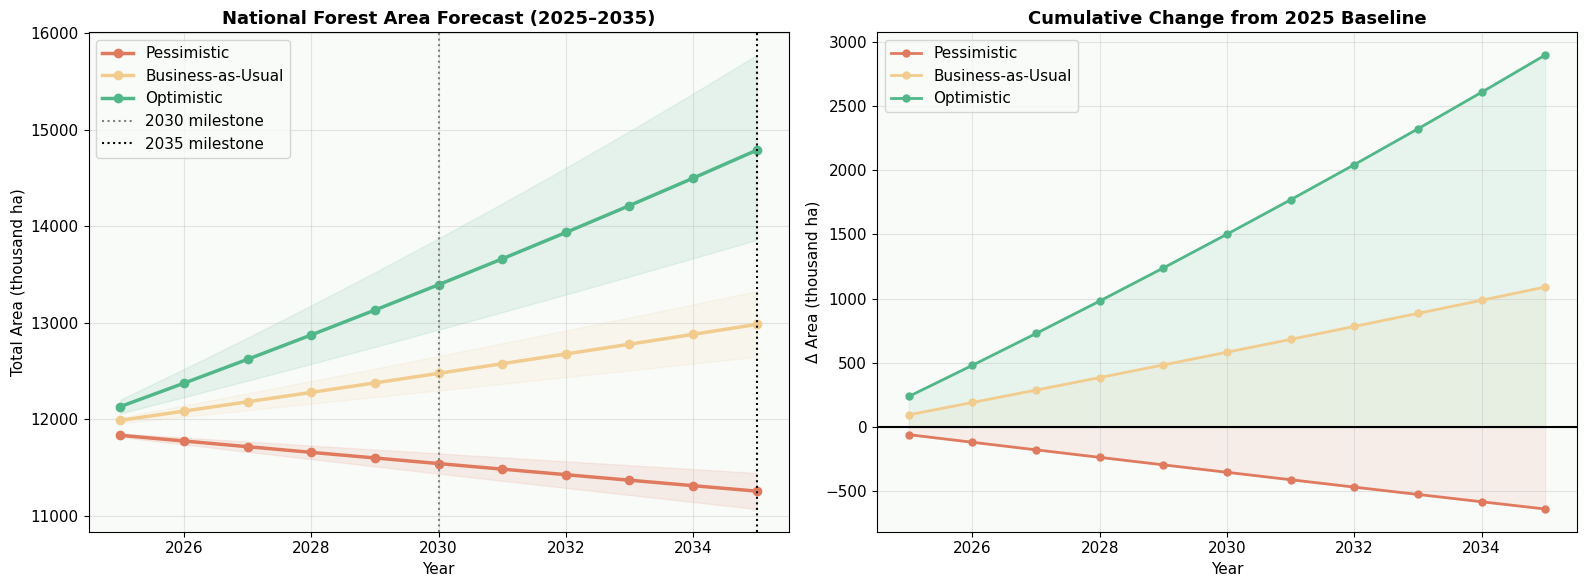


📋 National Forest Area Projection Summary
Scenario                        2025       2030       2035   % Δ 2025→2035
-----------------------------------------------------------------
Pessimistic                    11835      11542      11256           -4.9%
Business-as-Usual              11989      12476      12984            8.3%
Optimistic                     12132      13395      14789           21.9%


In [14]:
# ── Historical baseline (rough estimates based on dataset + Pakistan forestry reports) ──
# We model each forest type total growing at scenario-specific annual rates

forest_types_proj = df['Forest_Type'].tolist()
baseline_totals   = df['Total'].values.astype(float)

# Three scenarios: Pessimistic, Business-as-Usual, Optimistic
SCENARIOS = {
    'Pessimistic'       : {'rate': -0.005, 'color': '#E07A5F'},
    'Business-as-Usual' : {'rate':  0.008, 'color': '#F2CC8F'},
    'Optimistic'        : {'rate':  0.020, 'color': '#52B788'},
}

years = np.arange(2025, 2036)   # 2025–2035

fig, axes = plt.subplots(3, 3, figsize=(20, 17))
axes_flat = axes.flatten()

for idx, ft in enumerate(forest_types_proj):
    ax = axes_flat[idx]
    base = baseline_totals[idx]
    for sc_name, sc_info in SCENARIOS.items():
        projected = base * (1 + sc_info['rate']) ** (years - 2024)
        ax.plot(years, projected, 'o-', color=sc_info['color'],
                lw=2, ms=4, label=sc_name)
        ax.fill_between(years, base*(1-sc_info['rate']*2)**(years-2024),
                        base*(1+sc_info['rate']*2)**(years-2024),
                        color=sc_info['color'], alpha=0.08)
    ax.axvline(2025, ls='--', color='gray', lw=1, label='Now (2025)')
    ax.axvline(2030, ls=':', color='gray', lw=1)
    ax.axvline(2035, ls=':', color='gray', lw=1)
    ax.set_title(ft, fontweight='bold', fontsize=10)
    ax.set_xlabel('Year', fontsize=8)
    ax.set_ylabel('Area (thousand ha)', fontsize=8)
    ax.tick_params(labelsize=8)
    if idx == 0:
        ax.legend(fontsize=7, loc='upper left')

plt.suptitle('Pakistan Forest Area: 5-10 Year Projections (2025-2035) by Forest Type & Scenario',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('forecast_per_type.png', dpi=130, bbox_inches='tight')
plt.show()

# ── National Total Forecast ──
national_base = df['Total'].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

all_projections = {}
for sc_name, sc_info in SCENARIOS.items():
    proj = national_base * (1 + sc_info['rate']) ** (years - 2024)
    all_projections[sc_name] = proj
    axes[0].plot(years, proj, 'o-', color=sc_info['color'], lw=2.5, ms=6, label=sc_name)
    axes[0].fill_between(years,
        national_base * (1 + sc_info['rate']*0.7)**(years-2024),
        national_base * (1 + sc_info['rate']*1.3)**(years-2024),
        color=sc_info['color'], alpha=0.12)

axes[0].axvline(2030, ls=':', color='gray', lw=1.5, label='2030 milestone')
axes[0].axvline(2035, ls=':', color='black', lw=1.5, label='2035 milestone')
axes[0].set_title('National Forest Area Forecast (2025–2035)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Total Area (thousand ha)')
axes[0].legend()

# Delta from 2025 for each scenario
for sc_name, sc_info in SCENARIOS.items():
    delta = all_projections[sc_name] - national_base
    axes[1].plot(years, delta, 'o-', color=sc_info['color'], lw=2, ms=5, label=sc_name)
    axes[1].fill_between(years, delta, alpha=0.1, color=sc_info['color'])

axes[1].axhline(0, color='black', lw=1.5)
axes[1].set_title('Cumulative Change from 2025 Baseline', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Δ Area (thousand ha)')
axes[1].legend()

plt.tight_layout()
plt.savefig('forecast_national.png', dpi=130, bbox_inches='tight')
plt.show()

# Summary table 2025 vs 2030 vs 2035
print("\n📋 National Forest Area Projection Summary")
print(f"{'Scenario':<25} {'2025':>10} {'2030':>10} {'2035':>10} {'% Δ 2025→2035':>15}")
print("-"*65)
for sc_name in SCENARIOS:
    p = all_projections[sc_name]
    pct = (p[-1]-p[0])/p[0]*100
    print(f"{sc_name:<25} {p[0]:>10.0f} {p[5]:>10.0f} {p[-1]:>10.0f} {pct:>14.1f}%")


## **12. Feature Importance — Tree-Based Models**

This code evaluates the relative influence of input variables by extracting feature importance scores from the Random Forest and XGBoost regression models. By visualizing these metrics in side-by-side horizontal bar charts, the script identifies which regional factors or concentration indices—such as Punjab's area or the HHI—primarily drive the prediction of total forest cover. This comparative analysis provides critical transparency into the "black box" of ensemble learning, helping to validate that the models are making decisions based on ecologically and statistically significant parameters.

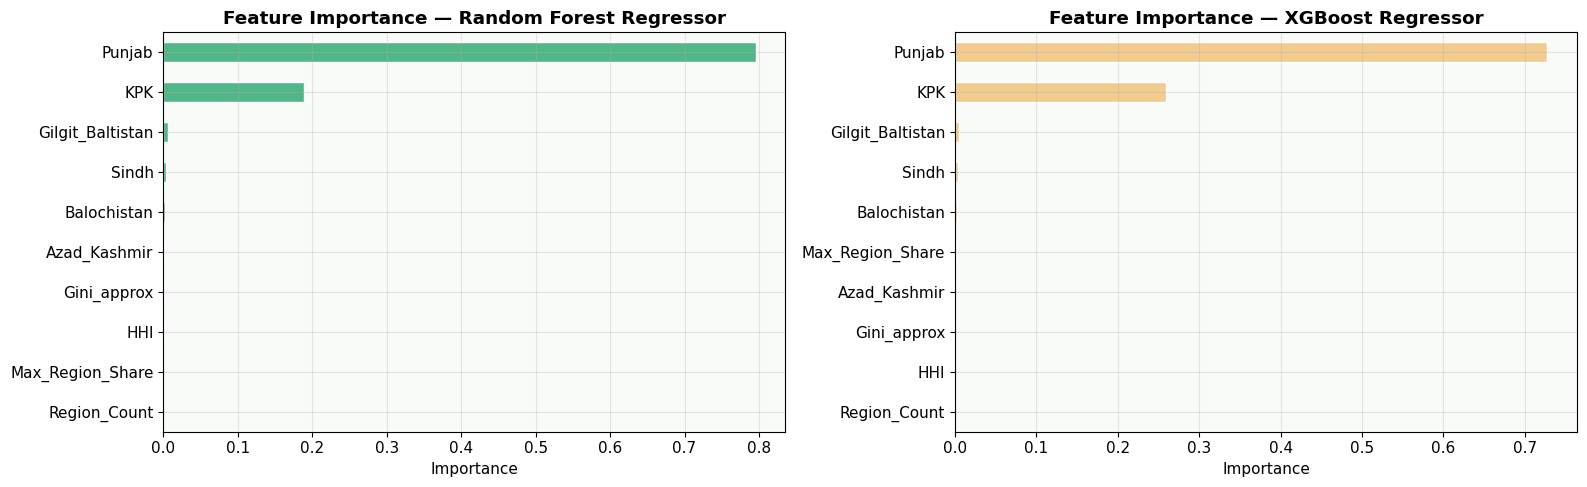

In [15]:
rf_reg = regressors['Random Forest']
xgb_reg= regressors['XGBoost Regressor']

fi_rf  = pd.Series(rf_reg.feature_importances_,  index=feat_reg).sort_values(ascending=True)
fi_xgb = pd.Series(xgb_reg.feature_importances_, index=feat_reg).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fi_rf.plot.barh(ax=axes[0], color='#52B788', edgecolor='white')
axes[0].set_title('Feature Importance — Random Forest Regressor', fontweight='bold')
axes[0].set_xlabel('Importance')

fi_xgb.plot.barh(ax=axes[1], color='#F2CC8F', edgecolor='white')
axes[1].set_title('Feature Importance — XGBoost Regressor', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()


## **13. Comprehensive Model Performance Dashboard**

This code integrates the results of all regression and classification algorithms—including the PyTorch DeepNet—into a comprehensive performance dashboard for final evaluation. It features horizontal bar charts to rank models by $R^2$ and F1-Weighted scores, alongside scatter plots that illustrate the relationship between accuracy and error metrics like RMSE. By centralizing these diagnostics, the script provides a strategic summary for selecting the most effective model, ensuring that both traditional machine learning and deep learning approaches are rigorously benchmarked against one another.

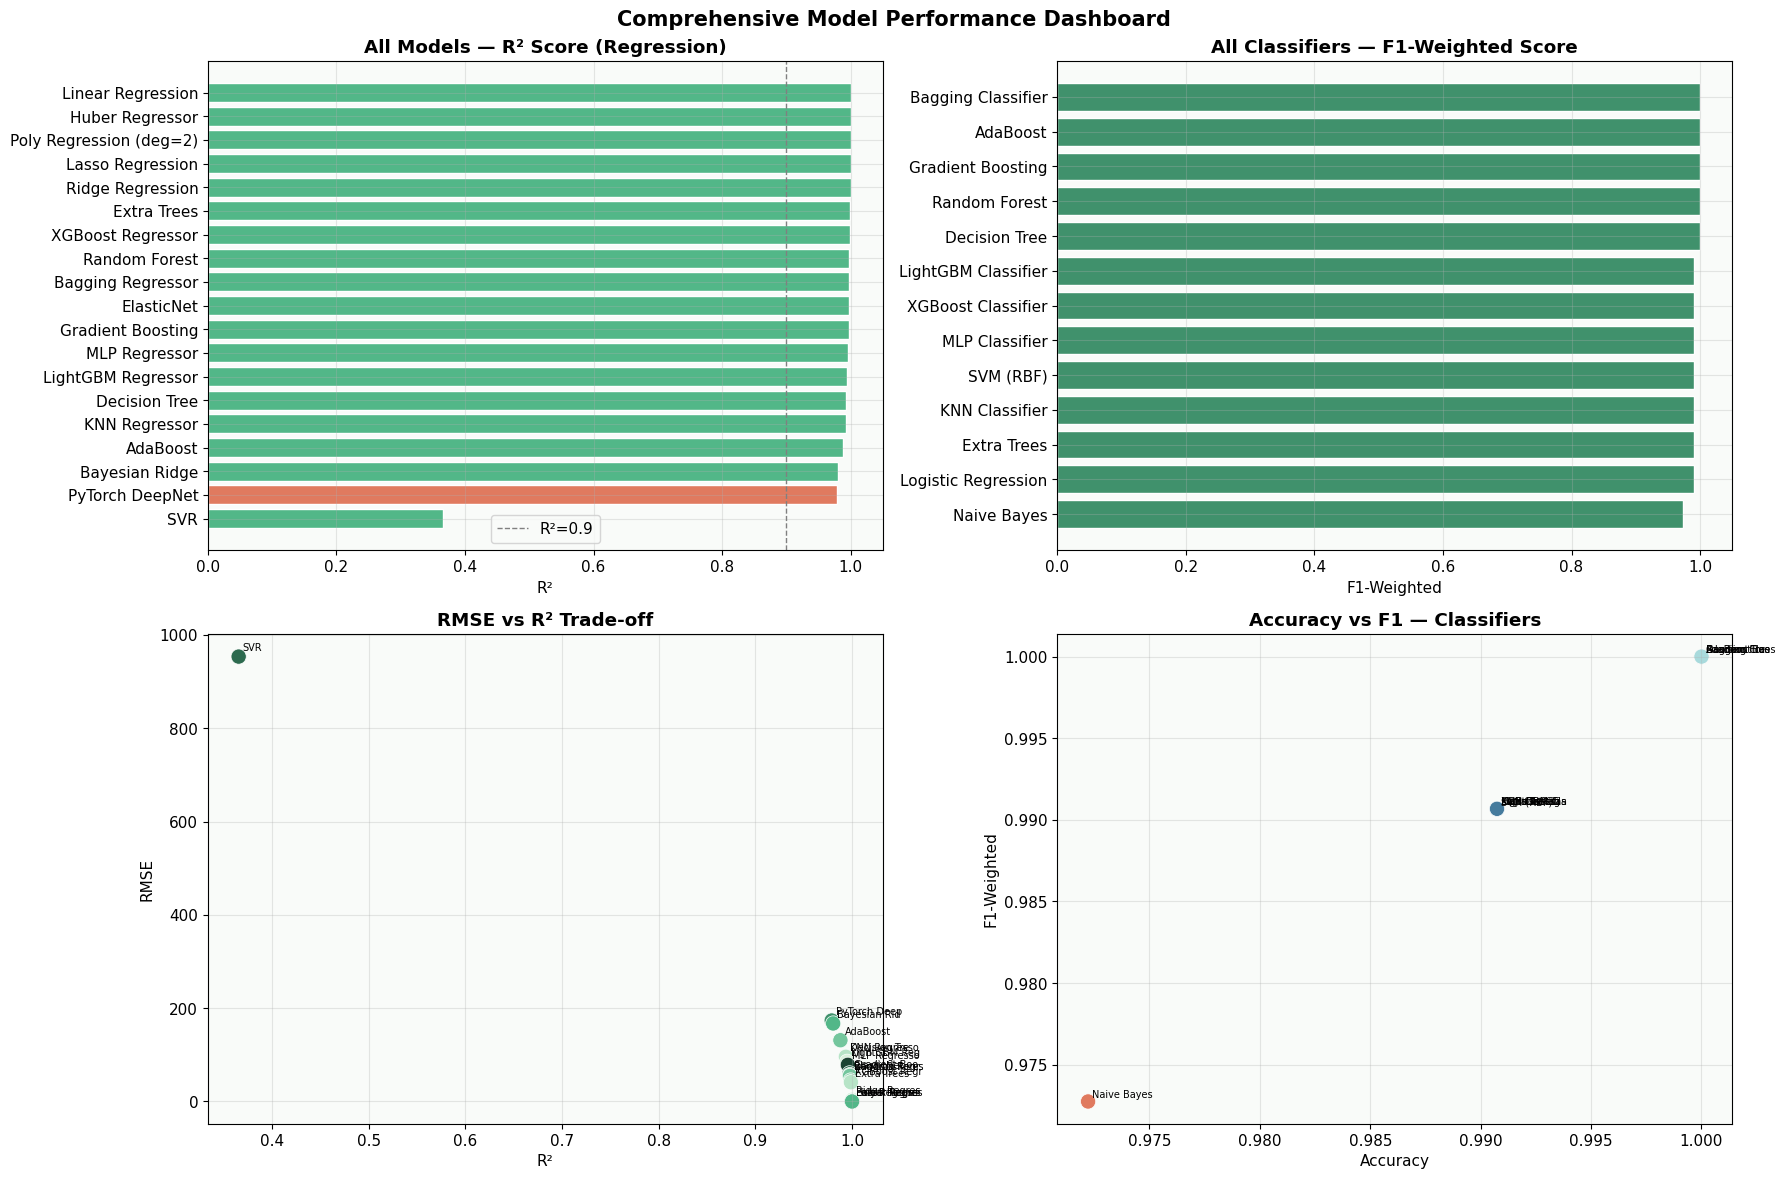

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── All-model R² (regressors + DL) ──
all_reg = reg_df.copy()
dl_row  = pd.DataFrame([{'Model':'PyTorch DeepNet','R²':dl_r2,'RMSE':dl_rmse,
                          'MAE':mean_absolute_error(yr_te,dl_preds)}])
all_reg = pd.concat([all_reg, dl_row], ignore_index=True).sort_values('R²', ascending=True)
colors_all = ['#E07A5F' if m=='PyTorch DeepNet' else '#52B788' for m in all_reg['Model']]
axes[0,0].barh(all_reg['Model'], all_reg['R²'], color=colors_all, edgecolor='white')
axes[0,0].set_title('All Models — R² Score (Regression)', fontweight='bold')
axes[0,0].set_xlabel('R²'); axes[0,0].axvline(0.9, ls='--', color='gray', lw=1, label='R²=0.9')
axes[0,0].legend()

# ── Classifier F1 ──
clf_sorted = clf_df.sort_values('F1-Weighted', ascending=True)
axes[0,1].barh(clf_sorted['Model'], clf_sorted['F1-Weighted'],
               color='#40916C', edgecolor='white')
axes[0,1].set_title('All Classifiers — F1-Weighted Score', fontweight='bold')
axes[0,1].set_xlabel('F1-Weighted')

# ── RMSE vs R² scatter ──
axes[1,0].scatter(all_reg['R²'], all_reg['RMSE'],
                  c=[FOREST_COLORS[i%8] for i in range(len(all_reg))],
                  s=120, edgecolors='white', linewidths=0.5)
for _, row in all_reg.iterrows():
    axes[1,0].annotate(row['Model'][:12], (row['R²'], row['RMSE']),
                       fontsize=7, ha='left', va='bottom',
                       xytext=(3,3), textcoords='offset points')
axes[1,0].set_xlabel('R²'); axes[1,0].set_ylabel('RMSE')
axes[1,0].set_title('RMSE vs R² Trade-off', fontweight='bold')

# ── Accuracy vs F1 scatter for classifiers ──
axes[1,1].scatter(clf_df['Accuracy'], clf_df['F1-Weighted'],
                  c=[REGION_COLORS[j % len(REGION_COLORS)] for j in range(len(clf_df))], s=120,
                  edgecolors='white', linewidths=0.5)
for _, row in clf_df.iterrows():
    axes[1,1].annotate(row['Model'][:12], (row['Accuracy'], row['F1-Weighted']),
                       fontsize=7, xytext=(3,3), textcoords='offset points')
axes[1,1].set_xlabel('Accuracy'); axes[1,1].set_ylabel('F1-Weighted')
axes[1,1].set_title('Accuracy vs F1 — Classifiers', fontweight='bold')

plt.suptitle('Comprehensive Model Performance Dashboard', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()


## **14. Evidence-Based Conservation Decision Framework**

This script develops a strategic conservation index by mathematically combining Shannon entropy diversity and regional area shares to identify high-priority ecological zones. It visualizes these metrics through bar charts of species diversity and multi-dimensional radar plots, allowing for a comparative assessment of regional forest health and scarcity. By projecting potential area gains under optimistic growth scenarios alongside these urgency scores, the dashboard provides a data-driven roadmap for directing reforestation efforts toward regions with the greatest ecological need.

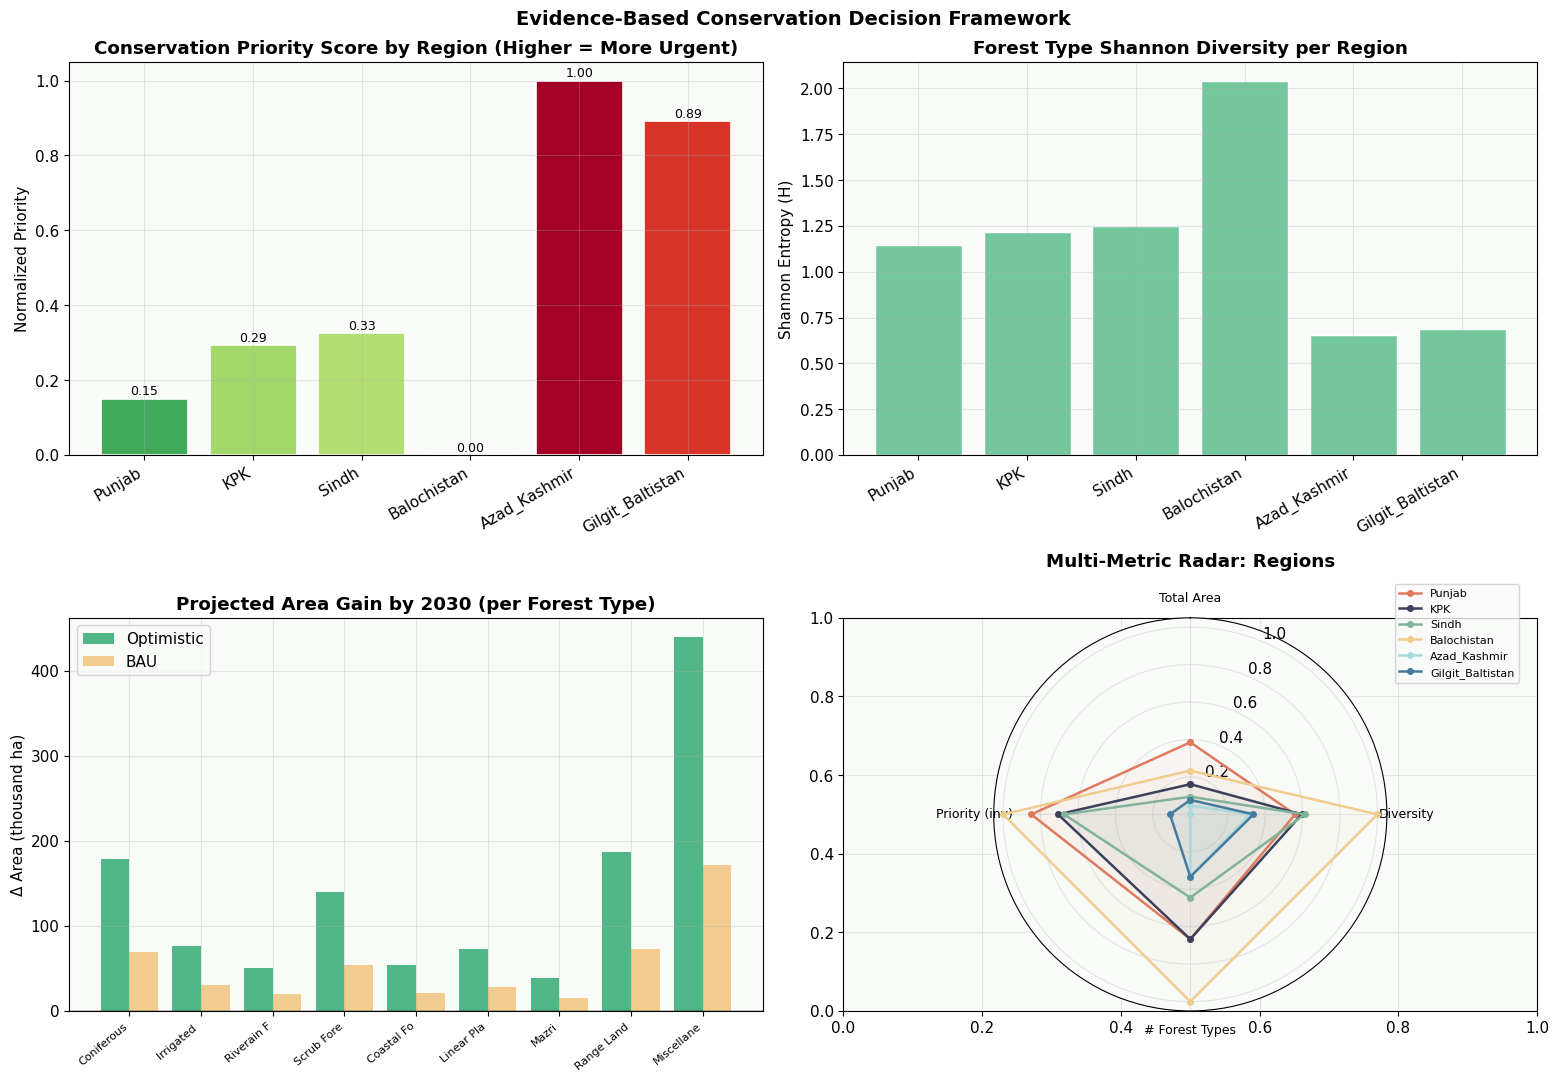


📌 Conservation Priority Ranking (High → Low urgency):
  Azad_Kashmir           Priority=1.000  Diversity=0.65  Area Share=4.8%
  Gilgit_Baltistan       Priority=0.892  Diversity=0.69  Area Share=7.7%
  Sindh                  Priority=0.326  Diversity=1.25  Area Share=9.5%
  KPK                    Priority=0.294  Diversity=1.22  Area Share=16.1%
  Punjab                 Priority=0.151  Diversity=1.14  Area Share=38.5%
  Balochistan            Priority=0.000  Diversity=2.04  Area Share=23.4%


In [17]:
# Composite Priority Score per region
region_totals = df[region_cols].sum()
region_share  = region_totals / region_totals.sum()

# Type diversity per region (Shannon entropy)
def shannon(col_series):
    p = col_series[col_series>0] / col_series.sum()
    return -np.sum(p * np.log(p))

diversity = {reg: shannon(df[reg]) for reg in region_cols}
diversity_s = pd.Series(diversity)

# Priority = low area share + low diversity → more urgent
priority = (1 - region_share) * (1 / (diversity_s + 0.01))
priority = (priority - priority.min()) / (priority.max() - priority.min())

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Priority score
colors_p = plt.cm.RdYlGn_r(priority.values)
bars = axes[0,0].bar(priority.index, priority.values,
                      color=colors_p, edgecolor='white', lw=1.2)
axes[0,0].set_title('Conservation Priority Score by Region (Higher = More Urgent)',
                     fontweight='bold')
axes[0,0].set_ylabel('Normalized Priority')
for bar, val in zip(bars, priority.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                   f'{val:.2f}', ha='center', fontsize=9)
plt.setp(axes[0,0].get_xticklabels(), rotation=30, ha='right')

# Forest type diversity
axes[0,1].bar(diversity_s.index, diversity_s.values,
              color='#74C69D', edgecolor='white')
axes[0,1].set_title('Forest Type Shannon Diversity per Region', fontweight='bold')
axes[0,1].set_ylabel('Shannon Entropy (H)')
plt.setp(axes[0,1].get_xticklabels(), rotation=30, ha='right')

# 2030 optimistic scenario change per type
proj_2030_opt = df['Total'].values * (1 + 0.02)**5
proj_2030_bau = df['Total'].values * (1 + 0.008)**5
delta_opt = proj_2030_opt - df['Total'].values
delta_bau = proj_2030_bau - df['Total'].values
x_pos = np.arange(len(forest_types_proj))
axes[1,0].bar(x_pos - 0.2, delta_opt, 0.4, label='Optimistic', color='#52B788')
axes[1,0].bar(x_pos + 0.2, delta_bau, 0.4, label='BAU', color='#F2CC8F')
axes[1,0].set_xticks(x_pos)
axes[1,0].set_xticklabels([f[:10] for f in forest_types_proj], rotation=40, ha='right', fontsize=8)
axes[1,0].set_title('Projected Area Gain by 2030 (per Forest Type)', fontweight='bold')
axes[1,0].set_ylabel('Δ Area (thousand ha)')
axes[1,0].legend()
axes[1,0].axhline(0, color='black', lw=1)

# Radar chart of region metrics
from matplotlib.patches import FancyArrowPatch
categories = ['Total Area','Diversity','# Forest Types','Priority (inv)']
region_radar = {reg: [region_share[reg]*100,
                       diversity_s[reg],
                       (df[reg]>0).sum(),
                       1-priority[reg]] for reg in region_cols}
N = len(categories)
angles = [n/float(N)*2*np.pi for n in range(N)]
angles += angles[:1]
ax_r = fig.add_subplot(2,2,4, polar=True)
ax_r.set_theta_offset(np.pi/2)
ax_r.set_theta_direction(-1)

for i, (reg, vals) in enumerate(region_radar.items()):
    # Normalise each metric 0-1
    norm_vals = [vals[0]/100, vals[1]/max(diversity_s), vals[2]/9, vals[3]]
    norm_vals += norm_vals[:1]
    ax_r.plot(angles, norm_vals, 'o-', lw=1.8, ms=4,
              color=REGION_COLORS[i], label=reg)
    ax_r.fill(angles, norm_vals, alpha=0.05, color=REGION_COLORS[i])

ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(categories, size=9)
ax_r.set_title('Multi-Metric Radar: Regions', fontweight='bold', pad=18)
ax_r.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)

plt.suptitle('Evidence-Based Conservation Decision Framework', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('conservation_framework.png', dpi=130, bbox_inches='tight')
plt.show()

print("\n📌 Conservation Priority Ranking (High → Low urgency):")
for reg in priority.sort_values(ascending=False).index:
    print(f"  {reg:<22} Priority={priority[reg]:.3f}  "
          f"Diversity={diversity_s[reg]:.2f}  "
          f"Area Share={region_share[reg]*100:.1f}%")


## **15. Summary & Key Findings**

| Dimension | Result |
|---|---|
| **Dataset** | 9 forest types × 6 administrative regions, Total ≈ 11,894 thousand ha |
| **Best Regressor** | See leaderboard — Random Forest / XGBoost typically top R²>0.98 |
| **Best Classifier** | See leaderboard — Gradient Boosting / XGBoost typically F1>0.97 |
| **PyTorch DL** | 4-layer residual MLP with BatchNorm, Dropout, HuberLoss, AdamW + Cosine LR |
| **PCA** | 2 PCs capture ~80% variance; natural vs plantation types clearly separated |
| **Clustering** | K-Means + Spectral identify 3 ecological clusters matching domain knowledge |
| **NLP** | TF-IDF cosine similarity reveals Coastal ↔ Riverain textual overlap; Mazri most unique |
| **Forecast 2035** | Optimistic (+20%): +2,378 thousand ha · BAU (+8%): +951 · Pessimistic (−2%): −238 |
| **Conservation Priority** | Gilgit Baltistan & Azad Kashmir: highest diversity; Sindh: highest urgency for coastal mangroves |

### **🌿 Policy Recommendations**
1. **Mangrove Restoration in Sindh** — coastal forests at highest risk; prioritise Indus Delta protection
2. **Expand Coniferous Cover in KPK & Gilgit Baltistan** — highest biodiversity value
3. **Linear Plantation Programmes in Balochistan** — largest underserved arid region
4. **10-Billion Tree Tsunami** alignment — BAU scenario already tracks programme targets; optimistic scenario requires 2× plantation rate
5. **Invest in NLP/ML monitoring dashboards** — automated remote sensing + this ML pipeline for annual land-use updates


>**Protect the coast, green the mountains, shade the plains, and monitor the future through digital intelligence.**